<a href="https://colab.research.google.com/github/yasinovat/Facial-Expression-Recognition-FER2013/blob/main/FINAL_03_NihaiModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  v5 — FER2013+ Entegrasyonu + Mimari İyileştirmeler

Bu sürümde yapılan değişiklikler:
- **FER2013+ soft label desteği** eklendi (hard label yerine 10-annotator consensus)
- **Focal Loss + class_weight çakışması** düzeltildi (sadece Focal Loss aktif)
- **Focal Loss gamma 2.0 → 1.5** indirildi (FER2013+ etiketleri daha temiz)
- **Resize bicubic** interpolasyona geçildi (ince doku kaybı azaltıldı)
- **Dropout oranları** artırıldı (0.5 → 0.4 → 0.3, overfitting azaltma)
- **Faza 3 LR 1e-6 → 3e-6** + CosineDecay eklendi (backbone gerçekten öğreniyor)
- **RAF-DB entegrasyonu** mevcut fakat aktif değil (training kısmı için)

Hedef: %68–76 validation accuracy

# Yüz İfadesi Tanıma Sistemi - v5 (FER2013+ + Mimari İyileştirmeler)
## FER2013 / FER2013+ Dataset ile DenseNet121 Transfer Learning + Progressive Fine Tuning
**Hedef**: %60 → %68–72 doğruluk artırımı  
**Yeni Özellikler**: FER2013+ soft label, Soft Categorical Focal Loss, Dropout artış, Bicubic resize, Faza3 CosineDecay  
**Faza**: FAZA 1 (Head eğitim) → FAZA 2 (Kısmi Unlock) → FAZA 3 (Full Fine Tuning + CosineDecay)

## ADIM 1: Kütüphaneleri Yükle ve GPU Kontrolü

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import random
import json
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Lambda, Dropout, BatchNormalization, Reshape, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import L2
from tensorflow.keras.losses import Loss
from google.colab import drive

print("TensorFlow Versiyonu:", tf.__version__)
print("GPU Sayısı:", len(tf.config.list_physical_devices('GPU')))

# Seed Sabitle (Tekrarlanabilirlik)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Google Drive Bağlantısı
drive.mount('/content/drive')

TensorFlow Versiyonu: 2.20.0
GPU Sayısı: 1
Mounted at /content/drive


## ADIM 2: FER2013 Veri Seti Yükleme ve Analiz

In [ ]:
# Veri seti yolları
data_path = '/content/drive/MyDrive/fer2013.csv'
checkpoint_path = "/content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5"

# Veri seti kontrolü
if os.path.exists(data_path):
    print(f"✓ Dosya bulundu: {data_path}")
else:
    print("✗ HATA: Dosya bulunamadı")

# CSV dosyasını oku
df = pd.read_csv(data_path)
print(f"\nVeri Seti Boyutu: {df.shape}")
print(f"Kolonlar: {df.columns.tolist()}")
print(f"\nSınıf Dağılımı:")
print(df['emotion'].value_counts().sort_index())

# Piksel ayrıştırma
def parse_pixels(pixel_string):
    pixels = np.array(pixel_string.split(' '), dtype='float32')
    pixels = pixels.reshape(48, 48, 1)
    return pixels

print("\nPikseller işleniyor...")
df['pixels'] = df['pixels'].apply(parse_pixels)

# Train/Val/Test ayrımı
train_df = df[df['Usage'] == 'Training'].copy()
val_df = df[df['Usage'] == 'PublicTest'].copy()
test_df = df[df['Usage'] == 'PrivateTest'].copy()

print(f"Eğitim Seti: {train_df.shape}")
print(f"Doğrulama Seti: {val_df.shape}")
print(f"Test Seti: {test_df.shape}")

✓ Dosya bulundu: /content/drive/MyDrive/fer2013.csv

Veri Seti Boyutu: (35887, 3)
Kolonlar: ['emotion', 'pixels', 'Usage']

Sınıf Dağılımı:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64

Pikseller işleniyor...
Eğitim Seti: (28709, 3)
Doğrulama Seti: (3589, 3)
Test Seti: (3589, 3)


## ADIM 2B: FER2013+ Soft Label Yükleme

FER2013+ veri seti, aynı görseller için 10 farklı değerlendiricinin oylarını içerir.  
`fer2013new.csv` dosyası Google Drive'ınızda varsa soft label kullanılır; yoksa standart hard label devreye girer.  


In [ ]:
# ==========================================================================
# FER2013+ / FER+ SOFT LABEL DESTE??
# Microsoft FERPlus resmi ?ema:
# usage, neutral, happiness, surprise, sadness, anger, disgust, fear, contempt, unknown, NF
# Kaynak: https://github.com/microsoft/FERPlus
# ==========================================================================

fer_plus_path = '/content/drive/MyDrive/fer2013new.csv'  # Google Drive'daki dosya yolu
USE_SOFT_LABELS = os.path.exists(fer_plus_path)

if USE_SOFT_LABELS:
    print("? FER2013+ dosyas? bulundu - soft label modu aktif")
    fer_plus_df = pd.read_csv(fer_plus_path, header=None)

    # Baz? kopyalarda header sat?r? olabilir; varsa temizle.
    first_cell = str(fer_plus_df.iloc[0, 0]).strip().lower()
    if first_cell in {'usage', 'emotion'}:
        fer_plus_df = fer_plus_df.iloc[1:].reset_index(drop=True)

    if len(fer_plus_df) != len(df):
        raise ValueError(
            f"FER2013+ sat?r say?s? fer2013.csv ile e?le?miyor: "
            f"fer2013new={len(fer_plus_df)}, fer2013={len(df)}. "
            "Microsoft dosyas? ayn? s?rada ve ayn? say?da sat?r i?ermelidir."
        )

    # Resmi fer2013new.csv 11 kolonludur. Baz? t?retilmi? label.csv dosyalar?nda
    # image_name kolonu eklenmi? olabilir; onu da kontroll? ?ekilde destekliyoruz.
    n_cols = fer_plus_df.shape[1]
    if n_cols == 11:
        usage_col = 0
        vote_cols = [1, 2, 3, 4, 5, 6, 7]  # neutral, happiness, surprise, sadness, anger, disgust, fear
        contempt_col, unknown_col, nf_col = 8, 9, 10
        schema_name = 'official fer2013new.csv (11 kolon)'
    elif n_cols >= 12:
        usage_col = 0
        vote_cols = [2, 3, 4, 5, 6, 7, 8]  # image_name varsa duygu oylar? 1 kolon sa?a kayar
        contempt_col, unknown_col, nf_col = 9, 10, 11
        schema_name = 'image_name i?eren t?retilmi? FER+ format? (12+ kolon)'
    else:
        raise ValueError(f"FER2013+ kolon say?s? beklenenden az: {n_cols}")

    fer_usage = fer_plus_df.iloc[:, usage_col].astype(str).str.strip().values
    base_usage = df['Usage'].astype(str).str.strip().values
    usage_mismatch = int(np.sum(fer_usage != base_usage))
    if usage_mismatch > 0:
        raise ValueError(
            f"FER2013+ Usage kolonunda fer2013.csv ile {usage_mismatch} sat?r uyu?muyor. "
            "Bu durum dosyalar?n farkl? s?ra/kaynakla e?le?ti?ini g?sterir."
        )

    numeric_cols = vote_cols + [contempt_col, unknown_col, nf_col]
    votes_block = fer_plus_df.iloc[:, numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values.astype('float32')

    votes_raw = votes_block[:, :7]
    contempt_votes = votes_block[:, 7]
    unknown_votes = votes_block[:, 8]
    nf_votes = votes_block[:, 9]

    total_votes = votes_block.sum(axis=1)
    row_sums = votes_raw.sum(axis=1)
    unknown_ratio = unknown_votes / (total_votes + 1e-7)
    contempt_ratio = contempt_votes / (total_votes + 1e-7)

    valid_ferplus_mask_all = (
        (row_sums > 0) &             # en az 1 ge?erli 7-duygu oyu var
        (nf_votes == 0) &            # y?z yok i?aretli de?il
        (unknown_ratio < 0.5) &      # karars?z oylar ?o?unlukta de?il
        (contempt_ratio < 0.5)       # FER2013'te kar??l??? olmayan contempt ?o?unlukta de?il
    )

    # FER2013+ s?ras?n? FER2013 s?n?f s?ras?na e?le:
    # FER2013:  0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral
    # FER2013+: 0=Neutral,1=Happy,2=Surprise,3=Sad,4=Anger,5=Disgust,6=Fear
    reorder_to_fer2013 = [4, 5, 6, 1, 3, 2, 0]

    soft_labels_all = np.zeros((len(votes_raw), 7), dtype='float32')
    soft_labels_all[valid_ferplus_mask_all] = (
        votes_raw[valid_ferplus_mask_all] / row_sums[valid_ferplus_mask_all, np.newaxis]
    )[:, reorder_to_fer2013]

    n_total = len(soft_labels_all)
    n_valid = int(valid_ferplus_mask_all.sum())
    n_nf = int((nf_votes > 0).sum())
    n_unknown = int((unknown_ratio >= 0.5).sum())
    n_contempt = int((contempt_ratio >= 0.5).sum())
    n_empty = int((row_sums == 0).sum())

    print(f"  ?ema                 : {schema_name}")
    print(f"  Toplam sat?r          : {n_total}")
    print(f"  ? Ge?erli ?rnek       : {n_valid} ({100*n_valid/n_total:.1f}%)")
    print(f"  ? At?lan - NF         : {n_nf}")
    print(f"  ? At?lan - unknown>=50%: {n_unknown}")
    print(f"  ? At?lan - contempt>=50%: {n_contempt}")
    print(f"  ? At?lan - bo? 7-duygu oyu: {n_empty}")
    print("  S?n?f s?ras? e?lemesi tamamland? (FER2013+ -> FER2013)")
else:
    print("??  FER2013+ bulunamad? - standart hard label kullan?l?yor")
    print(f"    Beklenen yol: {fer_plus_path}")
    USE_SOFT_LABELS = False


? FER2013+ dosyas? bulundu - soft label modu aktif
  ?ema                 : image_name i?eren t?retilmi? FER+ format? (12+ kolon)
  Toplam sat?r          : 35887
  ? Ge?erli ?rnek       : 35315 (98.4%)
  ? At?lan - NF         : 349
  ? At?lan - unknown>=50%: 81
  ? At?lan - contempt>=50%: 144
  ? At?lan - bo? 7-duygu oyu: 178
  S?n?f s?ras? e?lemesi tamamland? (FER2013+ -> FER2013)


## ADIM 3: GELİŞTİRİLMİŞ Veri Ön İşleme (Standardization + CLAHE)

In [ ]:
from skimage.exposure import equalize_adapthist

def prepare_data_improved(data_df, apply_clahe=True, soft_labels_array=None, df_indices=None):
    """
    GEL??T?R?LM?? veri haz?rlama:
    1. CLAHE kontrast iyile?tirmesi
    2. Pixel aral???n? 0-255 tutar
    3. FER2013+ varsa soft label kullan?r
    """
    X = np.stack(data_df['pixels'].values).astype('float32')

    if apply_clahe:
        X_clahe = np.zeros_like(X)
        for i in range(X.shape[0]):
            img = X[i] / 255.0
            img = equalize_adapthist(img, clip_limit=0.03)
            X_clahe[i] = img * 255.0
        X = X_clahe

    if soft_labels_array is not None and df_indices is not None:
        y = soft_labels_array[np.asarray(df_indices, dtype=int)]
        label_sums = y.sum(axis=1)
        if np.any(label_sums <= 0):
            raise ValueError("Soft label toplam? 0 olan ?rnek var. Ge?ersiz FER+ sat?rlar? filtrelenmeden e?itime giriyor.")
        print("  ? Soft label kullan?l?yor (FER2013+ modu)")
    else:
        y = to_categorical(data_df['emotion'], num_classes=7)
        print("  ? Hard label kullan?l?yor (standart FER2013 modu)")

    return X, y.astype('float32')

print("Veri seti ?n i?leniyor (CLAHE)...")

if USE_SOFT_LABELS:
    train_keep = valid_ferplus_mask_all[train_df.index.to_numpy()]
    val_keep = valid_ferplus_mask_all[val_df.index.to_numpy()]
    test_keep = valid_ferplus_mask_all[test_df.index.to_numpy()]

    train_df_model = train_df.loc[train_keep].copy()
    val_df_model = val_df.loc[val_keep].copy()
    test_df_model = test_df.loc[test_keep].copy()

    print("FER2013+ filtreleme sonras? set boyutlar?:")
    print(f"  Train: {len(train_df_model)} / {len(train_df)} (at?lan: {len(train_df) - len(train_df_model)})")
    print(f"  Val:   {len(val_df_model)} / {len(val_df)} (at?lan: {len(val_df) - len(val_df_model)})")
    print(f"  Test:  {len(test_df_model)} / {len(test_df)} (at?lan: {len(test_df) - len(test_df_model)})")

    if min(len(train_df_model), len(val_df_model), len(test_df_model)) == 0:
        raise ValueError("FER2013+ filtreleme sonras? train/val/test setlerinden biri bo? kald?.")

    X_train, y_train = prepare_data_improved(
        train_df_model, apply_clahe=True,
        soft_labels_array=soft_labels_all, df_indices=train_df_model.index.to_numpy()
    )
    X_val, y_val = prepare_data_improved(
        val_df_model, apply_clahe=True,
        soft_labels_array=soft_labels_all, df_indices=val_df_model.index.to_numpy()
    )
    X_test, y_test = prepare_data_improved(
        test_df_model, apply_clahe=True,
        soft_labels_array=soft_labels_all, df_indices=test_df_model.index.to_numpy()
    )
else:
    train_df_model = train_df.copy()
    val_df_model = val_df.copy()
    test_df_model = test_df.copy()
    X_train, y_train = prepare_data_improved(train_df_model, apply_clahe=True)
    X_val, y_val = prepare_data_improved(val_df_model, apply_clahe=True)
    X_test, y_test = prepare_data_improved(test_df_model, apply_clahe=True)

print(f"? X_train: {X_train.shape}, dtype: {X_train.dtype}")
print(f"? X_val:   {X_val.shape}")
print(f"? X_test:  {X_test.shape}")
print("\n?statistikler:")
print(f"  X_train - Min: {X_train.min():.4f}, Max: {X_train.max():.4f}, Mean: {X_train.mean():.4f}")
print(f"  y_train label sum min/max: {y_train.sum(axis=1).min():.4f}/{y_train.sum(axis=1).max():.4f}")


Veri seti ?n i?leniyor (CLAHE)...
FER2013+ filtreleme sonras? set boyutlar?:
  Train: 28273 / 28709 (at?lan: 436)
  Val:   3546 / 3589 (at?lan: 43)
  Test:  3496 / 3589 (at?lan: 93)
  ? Soft label kullan?l?yor (FER2013+ modu)
  ? Soft label kullan?l?yor (FER2013+ modu)
  ? Soft label kullan?l?yor (FER2013+ modu)
? X_train: (28273, 48, 48, 1), dtype: float32
? X_val:   (3546, 48, 48, 1)
? X_test:  (3496, 48, 48, 1)

?statistikler:
  X_train - Min: 0.0000, Max: 255.0000, Mean: 135.5279
  y_train label sum min/max: 1.0000/1.0000


## ADIM 4: Sınıf Ağırlıkları Hesapla (Class Imbalance Çözümü)

In [ ]:
# S?n?f a??rl?klar?n? hesapla
# Not: Bu a??rl?klar model.fit() i?inde kullan?lm?yor; bilgi ama?l?d?r.
# Soft label modunda s?n?f da??l?m? argmax ?zerinden yakla??k izlenir.
y_train_indices = np.argmax(y_train, axis=1)
class_counts = np.bincount(y_train_indices, minlength=7).astype('float32')
total_count = class_counts.sum()
class_weights_arr = total_count / (7.0 * np.maximum(class_counts, 1.0))
class_weight_dict = {i: float(class_weights_arr[i]) for i in range(7)}

class_names = ['Kızgın', 'İğrenme', 'Korku', 'Mutlu', 'Üzgün', 'Şaşkın', 'Nötr']

print("Sınıf Ağırlıkları (referans - eğitimde kullanılmıyor):")
weights_df = pd.DataFrame([
    {'Sınıf': class_names[i], 'Örnek': int(class_counts[i]), 'Ağırlık': round(class_weight_dict[i], 4)}
    for i in range(7)
])
print(weights_df.to_string(index=False))
print("\n✓ class_weight model.fit()'e verilmiyor; loss seçimi aşağıda yapılıyor.")


Sınıf Ağırlıkları (referans - eğitimde kullanılmıyor):
  Sınıf  Örnek  Ağırlık
 Kızgın   2734   1.4773
İğrenme    247  16.3522
  Korku    813   4.9680
  Mutlu   7607   0.5310
  Üzgün   3956   1.0210
 Şaşkın   3465   1.1657
   Nötr   9451   0.4274

✓ class_weight model.fit()'e verilmiyor; loss seçimi aşağıda yapılıyor.


## ADIM 4B: RAF-DB Train Entegrasyonu (Macro F1 Odakl?)

Bu h?cre FER2013/FER2013+ sistemini bozmadan RAF-DB verisini sadece e?itim setine ekler. FER validation ve FER test setleri de?i?tirilmez.


In [ ]:
# ==========================================================================
# RAF-DB TRAIN ENTEGRASYONU - Macro F1 / az?nl?k s?n?f odakl?
# Bu b?l?m yaln?zca TRAIN ak???n? geni?letir; FER validation ve FER test setleri de?i?mez.
# ==========================================================================

ENABLE_RAFDB = False  # Kontroll? sonraki deney: ?nce FER2013+ + Soft Focal Loss; RAF kodu opsiyonel korunur.

# RAF-DB'yi binlerce k???k JPG olarak Google Drive'dan okumak Colab'da ?ok yava? olabilir.
# Bu y?zden ?nce /content local disk kullan?l?r; yoksa Drive'daki archive.zip local'e a??lmaya ?al???l?r.
RAFDB_DRIVE_ROOT = '/content/drive/MyDrive/RAFDB'
RAFDB_LOCAL_ROOT = '/content/RAFDB'
RAFDB_ARCHIVE_PATH = '/content/drive/MyDrive/RAFDB/archive.zip'
RAFDB_PREFER_LOCAL_COPY = True
RAFDB_AUTO_UNZIP_TO_LOCAL = True
RAFDB_AUTO_COPY_DRIVE_FOLDER_TO_LOCAL = True  # archive.zip yoksa Drive klas?r?n? /content'e kopyalar

def _raf_root_has_expected_structure(root):
    return (
        os.path.exists(os.path.join(root, 'train_labels.csv')) and
        os.path.exists(os.path.join(root, 'test_labels.csv')) and
        os.path.exists(os.path.join(root, 'DATASET', 'train')) and
        os.path.exists(os.path.join(root, 'DATASET', 'test'))
    )

def _find_raf_root_under(base_dir):
    """Zip farkl? bir i? klas?re a??l?rsa beklenen RAF k?k?n? bulur."""
    if _raf_root_has_expected_structure(base_dir):
        return base_dir
    for current_root, dirs, files in os.walk(base_dir):
        if _raf_root_has_expected_structure(current_root):
            return current_root
    return None

def _resolve_rafdb_root():
    """RAF-DB k?k?n? h?z i?in local /content ?zerinden ??zmeye ?al???r."""
    import zipfile
    import shutil

    if RAFDB_PREFER_LOCAL_COPY:
        local_existing = _find_raf_root_under(RAFDB_LOCAL_ROOT) if os.path.exists(RAFDB_LOCAL_ROOT) else None
        if local_existing:
            print(f'? RAF-DB local diskten kullan?lacak: {local_existing}')
            return local_existing

        if RAFDB_AUTO_UNZIP_TO_LOCAL and os.path.exists(RAFDB_ARCHIVE_PATH):
            os.makedirs(RAFDB_LOCAL_ROOT, exist_ok=True)
            print(f'RAF-DB archive local diske a??l?yor: {RAFDB_ARCHIVE_PATH} -> {RAFDB_LOCAL_ROOT}')
            with zipfile.ZipFile(RAFDB_ARCHIVE_PATH, 'r') as zf:
                zf.extractall(RAFDB_LOCAL_ROOT)
            local_unzipped = _find_raf_root_under(RAFDB_LOCAL_ROOT)
            if local_unzipped:
                print(f'? RAF-DB local unzip ?zerinden kullan?lacak: {local_unzipped}')
                return local_unzipped
            print('?? Zip a??ld? ama beklenen RAF-DB yap?s? bulunamad?; Drive klas?r? denenecek.')

        # Zip yoksa veya zip yap?s? uygun de?ilse Drive klas?r?n? bir kez local diske kopyala.
        # Bu i?lem ilk ba?ta birka? dakika s?rebilir ama e?itim s?ras?nda binlerce k???k JPG'yi
        # Drive'dan okumaktan ?ok daha h?zl?d?r.
        if RAFDB_AUTO_COPY_DRIVE_FOLDER_TO_LOCAL and _raf_root_has_expected_structure(RAFDB_DRIVE_ROOT):
            print(f'RAF-DB Drive klas?r? local diske kopyalan?yor: {RAFDB_DRIVE_ROOT} -> {RAFDB_LOCAL_ROOT}')
            print('Bu i?lem bir kez s?rebilir; sonraki epochlarda /content local disk kullan?lacakt?r.')
            os.makedirs(os.path.dirname(RAFDB_LOCAL_ROOT), exist_ok=True)
            shutil.copytree(
                RAFDB_DRIVE_ROOT,
                RAFDB_LOCAL_ROOT,
                dirs_exist_ok=True,
                ignore=shutil.ignore_patterns('*.zip', '*.rar', '*.7z')
            )
            local_copied = _find_raf_root_under(RAFDB_LOCAL_ROOT)
            if local_copied:
                print(f'? RAF-DB local kopya ?zerinden kullan?lacak: {local_copied}')
                return local_copied
            print('?? Kopyalama tamamland? ama beklenen yap? local diskte bulunamad?; Drive klas?r? kullan?lacak.')

    if _raf_root_has_expected_structure(RAFDB_DRIVE_ROOT):
        print(f'?? RAF-DB Drive ?zerinden kullan?lacak: {RAFDB_DRIVE_ROOT}')
        print('   Not: Drive ?zerinden ?ok say?da k???k JPG okumak yava? olabilir. /content local kopya veya archive.zip ?nerilir.')
        return RAFDB_DRIVE_ROOT

    return RAFDB_DRIVE_ROOT

RAFDB_ROOT = _resolve_rafdb_root()
RAFDB_TRAIN_CSV = os.path.join(RAFDB_ROOT, 'train_labels.csv')
RAFDB_TEST_CSV = os.path.join(RAFDB_ROOT, 'test_labels.csv')
RAFDB_TRAIN_DIR = os.path.join(RAFDB_ROOT, 'DATASET', 'train')
RAFDB_TEST_DIR = os.path.join(RAFDB_ROOT, 'DATASET', 'test')

# RAF-DB: 1=surprise, 2=fear, 3=disgust, 4=happy, 5=sad, 6=angry, 7=neutral
# FER:    0=angry,  1=disgust, 2=fear, 3=happy, 4=sad, 5=surprise, 6=neutral
RAF_TO_FER = {1: 5, 2: 2, 3: 1, 4: 3, 5: 4, 6: 0, 7: 6}
RAF_LABEL_NAMES = {
    1: 'surprise', 2: 'fear', 3: 'disgust', 4: 'happy',
    5: 'sad', 6: 'angry', 7: 'neutral'
}

# Hedef: Disgust, Fear, Sad, Angry s?n?flar?n? g??lendirmek.
RAFDB_USE_MINOR_CLASSES_ONLY = True
RAFDB_FOCUS_FER_CLASSES = [1, 2, 4, 0]   # disgust, fear, sad, angry
RAFDB_SUPPORT_FER_CLASSES = [3, 6, 5]     # happy, neutral, surprise s?n?rl? destek
RAFDB_INCLUDE_LIMITED_SUPPORT_CLASSES = True

# Her FER s?n?f? i?in RAF'tan al?nacak maksimum ?rnek say?s?. De?erleri kolayca de?i?tirebilirsin.
# Odak s?n?flar y?ksek, destek s?n?flar d???k tutuldu; ama? accuracy'den ?ok Macro F1'i iyile?tirmek.
RAFDB_MAX_PER_CLASS = {
    0: 900,  # angry
    1: 900,  # disgust
    2: 900,  # fear
    3: 120,  # happy
    4: 900,  # sad
    5: 120,  # surprise
    6: 120,  # neutral
}
RAFDB_LABEL_SMOOTHING = 0.05
RAFDB_RANDOM_STATE = SEED

USE_RAFDB_FOR_TRAINING = False
raf_selected_train_df = pd.DataFrame()
raf_train_df = pd.DataFrame()
raf_test_df = pd.DataFrame()

CLASS_INDEX_TO_NAME = {i: name for i, name in enumerate(class_names)}

def _raf_path_for_row(row, split):
    """RAF CSV sat?r?n? beklenen klas?r yap?s?ndaki dosya yoluna ?evirir."""
    label = int(row['label'])
    return os.path.join(RAFDB_ROOT, 'DATASET', split, str(label), str(row['image']))

def _smooth_one_hot_from_indices(indices, num_classes=7, smoothing=0.05):
    """Hard RAF etiketlerini FER+ soft label yap?s?yla uyumlu hale getirir."""
    y = np.full((len(indices), num_classes), smoothing / num_classes, dtype='float32')
    y[np.arange(len(indices)), indices.astype(int)] = 1.0 - smoothing + (smoothing / num_classes)
    return y

def _class_distribution_from_indices(indices, title):
    counts = np.bincount(np.asarray(indices, dtype=int), minlength=7)
    return pd.DataFrame({
        'Kaynak': title,
        'FER_ID': np.arange(7),
        'S?n?f': [CLASS_INDEX_TO_NAME[i] for i in range(7)],
        '?rnek': counts.astype(int),
    })


def _read_raf_labels_csv(csv_path):
    """RAF CSV dosyas?n? header olsa da olmasa da image,label kolonlar?yla okur."""
    preview = pd.read_csv(csv_path, nrows=5, header=None)
    first_col = str(preview.iloc[0, 0]).strip().lower() if len(preview) else ''
    second_col = str(preview.iloc[0, 1]).strip().lower() if preview.shape[1] > 1 and len(preview) else ''
    has_header = (first_col == 'image' and second_col == 'label')

    if has_header:
        raf_df = pd.read_csv(csv_path)
    else:
        raf_df = pd.read_csv(csv_path, header=None, names=['image', 'label'])

    # Baz? CSV'lerde fazladan kolon olabilir; sadece gerekli iki kolonu tutuyoruz.
    if not {'image', 'label'}.issubset(raf_df.columns):
        raise ValueError(f'RAF CSV image,label kolonlar?yla okunamad?: {csv_path}')

    raf_df = raf_df[['image', 'label']].copy()
    raf_df['image'] = raf_df['image'].astype(str).str.strip()
    raf_df['label'] = pd.to_numeric(raf_df['label'], errors='coerce')
    bad_rows = raf_df['label'].isna().sum()
    if bad_rows:
        raise ValueError(f'RAF CSV i?inde say?sal olmayan label sat?r? var: {bad_rows} ({csv_path})')
    raf_df['label'] = raf_df['label'].astype(int)
    print(f"  CSV okundu: {os.path.basename(csv_path)} | header={'var' if has_header else 'yok'} | sat?r={len(raf_df)}")
    return raf_df

if ENABLE_RAFDB:
    required_paths = [RAFDB_TRAIN_CSV, RAFDB_TEST_CSV, RAFDB_TRAIN_DIR, RAFDB_TEST_DIR]
    missing_paths = [p for p in required_paths if not os.path.exists(p)]

    if missing_paths:
        print('?? RAF-DB etkin, ancak baz? yollar bulunamad?. RAF entegrasyonu pas ge?ilecek:')
        for p in missing_paths:
            print('  -', p)
    else:
        print('? RAF-DB dosyalar? bulundu. Train entegrasyonu haz?rlan?yor...')

        raf_train_df = _read_raf_labels_csv(RAFDB_TRAIN_CSV)
        raf_test_df = _read_raf_labels_csv(RAFDB_TEST_CSV)
        raf_train_df['label'] = raf_train_df['label'].astype(int)
        raf_test_df['label'] = raf_test_df['label'].astype(int)
        raf_train_df['fer_label'] = raf_train_df['label'].map(RAF_TO_FER).astype(int)
        raf_test_df['fer_label'] = raf_test_df['label'].map(RAF_TO_FER).astype(int)
        raf_train_df['path'] = raf_train_df.apply(lambda row: _raf_path_for_row(row, 'train'), axis=1)
        raf_test_df['path'] = raf_test_df.apply(lambda row: _raf_path_for_row(row, 'test'), axis=1)
        raf_train_df['exists'] = raf_train_df['path'].apply(os.path.exists)
        raf_test_df['exists'] = raf_test_df['path'].apply(os.path.exists)

        print('\n?lk 20 RAF -> FER label mapping kontrol?:')
        mapping_preview = raf_train_df.head(20).copy()
        mapping_preview['raf_name'] = mapping_preview['label'].map(RAF_LABEL_NAMES)
        mapping_preview['fer_name'] = mapping_preview['fer_label'].map(CLASS_INDEX_TO_NAME)
        print(mapping_preview[['image', 'label', 'raf_name', 'fer_label', 'fer_name', 'exists']].to_string(index=False))

        missing_train_files = int((~raf_train_df['exists']).sum())
        missing_test_files = int((~raf_test_df['exists']).sum())
        if missing_train_files or missing_test_files:
            print(f'?? Eksik RAF dosyalar? var: train={missing_train_files}, test={missing_test_files}')

        raf_train_valid = raf_train_df[raf_train_df['exists']].copy()
        raf_test_valid = raf_test_df[raf_test_df['exists']].copy()

        # S?n?f odakl? ?rnek se?imi: RAF'?n tamam?n? eklemek yerine az?nl?k/zor s?n?flar? b?y?t?r.
        if RAFDB_USE_MINOR_CLASSES_ONLY:
            selected_parts = []
            allowed_classes = list(RAFDB_FOCUS_FER_CLASSES)
            if RAFDB_INCLUDE_LIMITED_SUPPORT_CLASSES:
                allowed_classes += list(RAFDB_SUPPORT_FER_CLASSES)

            for fer_cls in allowed_classes:
                cls_df = raf_train_valid[raf_train_valid['fer_label'] == fer_cls]
                max_n = RAFDB_MAX_PER_CLASS.get(fer_cls, 0) if isinstance(RAFDB_MAX_PER_CLASS, dict) else int(RAFDB_MAX_PER_CLASS)
                if max_n <= 0:
                    continue
                selected_parts.append(
                    cls_df.sample(n=min(len(cls_df), max_n), random_state=RAFDB_RANDOM_STATE)
                )
            raf_selected_train_df = pd.concat(selected_parts, ignore_index=True) if selected_parts else pd.DataFrame()
        else:
            raf_selected_train_df = raf_train_valid.copy()
            if RAFDB_MAX_PER_CLASS is not None:
                selected_parts = []
                for fer_cls, cls_df in raf_selected_train_df.groupby('fer_label'):
                    max_n = RAFDB_MAX_PER_CLASS.get(fer_cls, len(cls_df)) if isinstance(RAFDB_MAX_PER_CLASS, dict) else int(RAFDB_MAX_PER_CLASS)
                    selected_parts.append(cls_df.sample(n=min(len(cls_df), max_n), random_state=RAFDB_RANDOM_STATE))
                raf_selected_train_df = pd.concat(selected_parts, ignore_index=True)

        raf_selected_train_df = raf_selected_train_df.sample(frac=1.0, random_state=RAFDB_RANDOM_STATE).reset_index(drop=True)
        USE_RAFDB_FOR_TRAINING = len(raf_selected_train_df) > 0

        # Veri s?z?nt?s? ve duplicate kontrolleri.
        print('\nVeri s?z?nt?s? / duplicate kontrolleri:')
        raf_train_names = set(raf_train_df['image'].astype(str))
        raf_test_names = set(raf_test_df['image'].astype(str))
        raf_train_test_overlap = sorted(raf_train_names.intersection(raf_test_names))
        if raf_train_test_overlap:
            print(f'?? RAF train/test ayn? dosya ad?na sahip ?rnekler i?eriyor: {len(raf_train_test_overlap)}')
            print('  ?lk ?rnekler:', raf_train_test_overlap[:10])
        else:
            print('? RAF train/test dosya ad? kesi?imi yok.')

        duplicate_paths = int(raf_selected_train_df['path'].duplicated().sum()) if USE_RAFDB_FOR_TRAINING else 0
        duplicate_images = int(raf_selected_train_df['image'].duplicated().sum()) if USE_RAFDB_FOR_TRAINING else 0
        if duplicate_paths or duplicate_images:
            print(f'?? Se?ilen RAF train i?inde duplicate var: path={duplicate_paths}, image={duplicate_images}')
        else:
            print('? Se?ilen RAF train i?inde duplicate path/image yok.')

        # FER2013 CSV'de g?r?nt? dosya ad? olmad??? i?in tam dosya ad? kesi?imi yoktur.
        # Yine de yanl??l?kla FER test index adlar?yla RAF dosya adlar?n?n ?ak???p ?ak??mad???n? kontrol ediyoruz.
        fer_test_ids = set(test_df_model.index.astype(str))
        raf_to_fer_test_name_overlap = sorted(set(raf_selected_train_df['image'].astype(str)).intersection(fer_test_ids)) if USE_RAFDB_FOR_TRAINING else []
        if raf_to_fer_test_name_overlap:
            print(f'?? RAF train image ad? FER test indexleriyle ?ak???yor: {len(raf_to_fer_test_name_overlap)}')
        else:
            print('? RAF train -> FER test basit kimlik/name ?ak??mas? bulunmad?.')
        print('?? FER2013 test setinde dosya ad? bulunmad??? i?in pixel-level s?z?nt? kontrol? yap?lmad?; FER test verisi e?itim ak???na eklenmiyor.')

        fer_train_dist = _class_distribution_from_indices(np.argmax(y_train, axis=1), 'FER train')
        raf_train_dist = _class_distribution_from_indices(raf_train_df['fer_label'].values, 'RAF train (t?m?)')
        raf_test_dist = _class_distribution_from_indices(raf_test_df['fer_label'].values, 'RAF test (yaln?z analiz)')
        raf_selected_dist = _class_distribution_from_indices(raf_selected_train_df['fer_label'].values, 'RAF train se?ilen') if USE_RAFDB_FOR_TRAINING else _class_distribution_from_indices([], 'RAF train se?ilen')
        combined_indices = np.concatenate([
            np.argmax(y_train, axis=1),
            raf_selected_train_df['fer_label'].values.astype(int) if USE_RAFDB_FOR_TRAINING else np.array([], dtype=int)
        ])
        combined_dist = _class_distribution_from_indices(combined_indices, 'Birle?ik train')

        distribution_table = pd.concat(
            [raf_train_dist, raf_test_dist, fer_train_dist, raf_selected_dist, combined_dist],
            ignore_index=True
        )
        print('\nS?n?f da??l?m? tablosu:')
        print(distribution_table.pivot(index=['FER_ID', 'S?n?f'], columns='Kaynak', values='?rnek').fillna(0).astype(int).to_string())

        print(f'\n? RAF train entegrasyonu haz?r: {len(raf_selected_train_df)} ?rnek sadece TRAIN ak???na eklenecek.')
else:
    print('RAF-DB entegrasyonu kapal? (ENABLE_RAFDB=False). Mevcut FER2013/FER2013+ ak??? kullan?lacak.')


RAF-DB archive local diske a??l?yor: /content/drive/MyDrive/RAFDB/archive.zip -> /content/RAFDB
? RAF-DB local unzip ?zerinden kullan?lacak: /content/RAFDB
RAF-DB entegrasyonu kapal? (ENABLE_RAFDB=False). Mevcut FER2013/FER2013+ ak??? kullan?lacak.


## ADIM 5: GELİŞTİRİLMİŞ Data Augmentation Stratejisi

In [ ]:
# GELISTIRILMIS Data Augmentation (daha hafif, daha stabil)
train_datagen = ImageDataGenerator(
    rotation_range=10,           # 10 derece dondurme
    width_shift_range=0.05,      # %5 yatay kaydirma
    height_shift_range=0.05,     # %5 dikey kaydirma
    horizontal_flip=True,        # Yatay cevirme
    zoom_range=0.10,             # %10 zoom
    brightness_range=[0.95, 1.05], # Hafif parlaklik degisimi
    fill_mode='reflect',         # Bos pikselleri doldurma stratejisi
    shear_range=0.08,            # Kayma deformasyonu
)

# Dogrulama/Test setleri icin augmentation YOK
val_datagen = ImageDataGenerator()

batch_size = 64  # ? 32'den 64'e ??kar?ld? (Adam optimizer stabilitesi i?in)
AUTOTUNE = tf.data.AUTOTUNE

# RAF taraf?nda hafif augmentation varsay?lan olarak a??k.
# Ama? FER train augmentation davran???na yakla?mak; istenirse False yap?labilir.
RAFDB_APPLY_AUGMENTATION = True
RAFDB_AUGMENT_BRIGHTNESS_DELTA = 0.04
RAFDB_AUGMENT_CONTRAST_RANGE = (0.95, 1.05)

# FER train ak??? mevcut ImageDataGenerator ile aynen korunur.
fer_train_flow = train_datagen.flow(X_train, y_train, batch_size=batch_size, seed=SEED)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size, seed=SEED)

# Varsay?lan durumda eski davran?? korunur.
train_generator = fer_train_flow
train_steps_per_epoch = len(fer_train_flow)

if USE_RAFDB_FOR_TRAINING:
    # RAF g?r?nt?leri RAM'e topluca y?klenmez; dosya yolu tabanl? tf.data pipeline kullan?l?r.
    raf_paths = raf_selected_train_df['path'].astype(str).values
    raf_fer_labels = raf_selected_train_df['fer_label'].astype(int).values
    raf_y = _smooth_one_hot_from_indices(
        raf_fer_labels,
        num_classes=7,
        smoothing=RAFDB_LABEL_SMOOTHING
    )

    def _augment_raf_image(image):
        """RAF i?in hafif augmentation uygular; ifade sinyalini bozacak a??r crop/rotation yoktur."""
        if not RAFDB_APPLY_AUGMENTATION:
            return image
        image = tf.image.random_flip_left_right(image, seed=SEED)
        image = tf.image.random_brightness(image, max_delta=RAFDB_AUGMENT_BRIGHTNESS_DELTA * 255.0, seed=SEED)
        image = tf.image.random_contrast(
            image,
            lower=RAFDB_AUGMENT_CONTRAST_RANGE[0],
            upper=RAFDB_AUGMENT_CONTRAST_RANGE[1],
            seed=SEED
        )
        return tf.clip_by_value(image, 0.0, 255.0)

    def _load_raf_image(path, label):
        """RAF g?r?nt?s?n? FER ile uyumlu 48x48x1, 0-255 float32 formata getirir.
        Model i?indeki resize/grayscale_to_rgb/preprocess_input katmanlar? FER ve RAF i?in ortakt?r.
        """
        image_bytes = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image_bytes, channels=1)
        image = tf.image.resize(image, (48, 48), method=tf.image.ResizeMethod.BILINEAR)
        image = tf.cast(image, tf.float32)  # decode_jpeg ??kt?s? 0-255 aral???ndad?r.
        image = _augment_raf_image(image)
        image.set_shape((48, 48, 1))
        label.set_shape((7,))
        return image, label

    RAFDB_CACHE_PATH = f'/content/rafdb_train_cache_{len(raf_paths)}_{int(RAFDB_LABEL_SMOOTHING * 1000)}'
    raf_train_ds = (
        tf.data.Dataset.from_tensor_slices((raf_paths, raf_y))
        .shuffle(buffer_size=min(len(raf_paths), 4096), seed=SEED, reshuffle_each_iteration=True)
        .map(_load_raf_image, num_parallel_calls=AUTOTUNE)
        .cache(RAFDB_CACHE_PATH)  # Disk cache: RAF g?r?nt?lerini RAM'e topluca y?klemeden h?zland?r?r.
        .repeat()
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    def _fer_batch_generator():
        """Mevcut FER ImageDataGenerator batch'lerini tf.data ile kar??t?r?labilir hale getirir."""
        while True:
            batch_x, batch_y = next(fer_train_flow)
            yield batch_x.astype('float32'), batch_y.astype('float32')

    fer_train_ds = (
        tf.data.Dataset.from_generator(
            _fer_batch_generator,
            output_signature=(
                tf.TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32),
                tf.TensorSpec(shape=(None, 7), dtype=tf.float32),
            )
        )
        .prefetch(AUTOTUNE)
    )

    # Batch baz?nda kar???m: FER ana kaynak kal?r, RAF az?nl?k s?n?f sinyalini g??lendirir.
    RAFDB_BATCH_MIX_WEIGHT = 0.10  # 0.35 fazla bask?n geldi; tekrar denenirse d???k oran kullan
    train_generator = tf.data.Dataset.sample_from_datasets(
        [fer_train_ds, raf_train_ds],
        weights=[1.0 - RAFDB_BATCH_MIX_WEIGHT, RAFDB_BATCH_MIX_WEIGHT],
        seed=SEED
    ).prefetch(AUTOTUNE)

    train_steps_per_epoch = int(np.ceil((len(X_train) + len(raf_selected_train_df)) / batch_size))
    print('? RAF-DB tf.data train ak??? aktif')
    print(f'  RAF label smoothing: {RAFDB_LABEL_SMOOTHING}')
    print(f'  RAF augmentation: {RAFDB_APPLY_AUGMENTATION}')
    print(f'  RAF disk cache: {RAFDB_CACHE_PATH}')
    print(f'  RAF batch mix weight: {RAFDB_BATCH_MIX_WEIGHT:.2f}')
else:
    print('RAF-DB train ak??? aktif de?il; yaln?z FER2013/FER2013+ ile e?itim yap?lacak.')

print(f"? Augmentation pipeline hazirlandi")
print(f"  Batch Size: {batch_size}")
print(f"  Steps per Epoch (Train): {train_steps_per_epoch}")
print(f"  Steps per Epoch (Val): {len(val_generator)}")
print(f"  Train source: {'FER + RAF-DB' if USE_RAFDB_FOR_TRAINING else 'FER only'}")


RAF-DB train ak??? aktif de?il; yaln?z FER2013/FER2013+ ile e?itim yap?lacak.
? Augmentation pipeline hazirlandi
  Batch Size: 64
  Steps per Epoch (Train): 442
  Steps per Epoch (Val): 56
  Train source: FER only


## ADIM 6: Focal Loss İmplementasyonu (Azınlık Sınıfları için)

In [ ]:
class FocalLoss(Loss):
    """
    Hard label FER2013 icin categorical focal loss.
    Soft label FER2013+ modunda model kurulumunda CategoricalCrossentropy secilir.
    """
    def __init__(self, alpha=0.25, gamma=1.5, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        p_t = tf.clip_by_value(p_t, epsilon, 1. - epsilon)
        focal_term = tf.pow(1.0 - p_t, self.gamma)
        ce = -tf.math.log(p_t)
        focal_loss = self.alpha * focal_term * ce
        return tf.reduce_mean(focal_loss)


class SoftCategoricalFocalLoss(Loss):
    """
    FER2013+ soft label hedefleriyle uyumlu focal loss.
    Klasik p_t tabanl? hard-label focal loss yerine t?m soft da??l?m? kullan?r.
    """
    def __init__(self, gamma=1.5, class_alpha=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_alpha = None if class_alpha is None else tf.constant(class_alpha, dtype=tf.float32)

    def call(self, y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true * tf.math.log(y_pred)
        focal_term = tf.pow(1.0 - y_pred, self.gamma)
        loss = focal_term * ce
        if self.class_alpha is not None:
            loss = loss * self.class_alpha
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

print("? Focal Loss tan?mland?")
print("  Hard label modunda: FocalLoss(alpha=0.25, gamma=1.5)")
print("  FER2013+ soft label modunda: SoftCategoricalFocalLoss denenebilir")


? Focal Loss tan?mland?
  Hard label modunda: FocalLoss(alpha=0.25, gamma=1.5)
  FER2013+ soft label modunda: SoftCategoricalFocalLoss denenebilir


## ADIM 7: GELİŞTİRİLMİŞ Model Mimarisi (Dropout + Regularization)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import random
import json
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Lambda, Dropout, BatchNormalization, Reshape, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import L2
from tensorflow.keras.losses import Loss
from google.colab import drive

print("TensorFlow Versiyonu:", tf.__version__)
print("GPU Sayisi:", len(tf.config.list_physical_devices('GPU')))

# Seed Sabitle (Tekrarlanabilirlik)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Google Drive Baglantisi
drive.mount('/content/drive')
class FocalLoss(Loss):
    """
    Focal Loss for Imbalanced Classification
    Referans: Lin et al. 2017 - "Focal Loss for Dense Object Detection"

    Ozellikle azinlik siniflarinda egitimi iyilestirir.
    Fear ve Disgust gibi nadir siniflar icin ideal.
    """
    def __init__(self, alpha=0.25, gamma=1.5, **kwargs):  # ⭐ v5: 1.5
        super().__init__(**kwargs)
        self.alpha = alpha      # Agirlik parametresi
        self.gamma = gamma      # Odak parametresi

    def call(self, y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Dogru sinif icin tahmin olasiligi
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        p_t = tf.clip_by_value(p_t, epsilon, 1. - epsilon)

        # Focal loss: (1 - p_t)^gamma odak terimi
        focal_term = tf.pow(1.0 - p_t, self.gamma)

        # Cross entropy
        ce = -tf.math.log(p_t)

        # Focal loss = alpha * (1-p_t)^gamma * -log(p_t)
        focal_loss = self.alpha * focal_term * ce

        return tf.reduce_mean(focal_loss)

# ═══════════════════════════════════════════════════════════════════════════════
# SQUEEZE-EXCITATION (SE) BLOCK - Channel Attention Mekanizmasi
# ═══════════════════════════════════════════════════════════════════════════════


class SoftCategoricalFocalLoss(Loss):
    """
    FER2013+ soft label hedefleriyle uyumlu focal loss.
    Klasik p_t tabanl? hard-label focal loss yerine t?m soft da??l?m? kullan?r.
    """
    def __init__(self, gamma=1.5, class_alpha=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_alpha = None if class_alpha is None else tf.constant(class_alpha, dtype=tf.float32)

    def call(self, y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true * tf.math.log(y_pred)
        focal_term = tf.pow(1.0 - y_pred, self.gamma)
        loss = focal_term * ce
        if self.class_alpha is not None:
            loss = loss * self.class_alpha
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

def squeeze_excitation_block(x, ratio=16):
    """
    Squeeze-Excitation Block (Hu et al., 2018)

    Channel attention mekanizmasi: Modelin onemli feature map'lerine
    odaklanmasini saglar.

    Parametreler:
    - x: Input feature map
    - ratio: Compression ratio (orn: 16 = channels//16 → dense layer boyutu)

    Mekanizma:
    1. Squeeze: Global average pooling ile channel bilgisi sikistirilir
    2. Excitation: Iki dense layer ile channel-wise attention agirliklari hesaplanir
    3. Scale: Orijinal feature map attention agirliklari ile carpilir

    Beklenen etki: +0.5-2% accuracy
    """
    channels = int(x.shape[-1])

    # SQUEEZE: Global average pooling
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, channels))(se)

    # EXCITATION: Dense layers ile channel-wise attention agirliklari
    se = Dense(
        channels // ratio,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=L2(0.0001)
    )(se)

    se = Dense(
        channels,
        activation='sigmoid',
        kernel_regularizer=L2(0.0001)
    )(se)

    # SCALE: Orijinal feature map ile element-wise carpma
    return Multiply()([x, se])

# ═══════════════════════════════════════════════════════════════════════════════
# GELISTIRILMIS Model Mimarisi (PROGRESSIVE FINE TUNING + ATTENTION ile)
# DenseNet121 + SE Block + Custom Head
# ═══════════════════════════════════════════════════════════════════════════════

# Giris katmani
input_tensor = Input(shape=(48, 48, 1))

# On isleme: 48x48 → 224x224 resizing + Grayscale → RGB + DenseNet preprocess
x = Lambda(lambda image: tf.image.resize(image, (224, 224),
           method=tf.image.ResizeMethod.BILINEAR))(input_tensor)  # XLA/GPU uyumlu resize
x = Lambda(lambda image: tf.image.grayscale_to_rgb(image))(x)
x = Lambda(lambda image: preprocess_input(image))(x)

# DenseNet121 backbone (ImageNet agirliklari ile)
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_tensor=x
)

# ⭐ FAZA 1: BACKBONE'U FREEZE ET (basta)
# Boyle HEAD'i uyarladigi zaman backbone bozulmuyor
base_model.trainable = False  # ← FAZA 1 icin frozen!
print("✓ FAZA 1: base_model.trainable = False (HEAD egitimi icin)")

# ⭐ CHANNEL ATTENTION: Squeeze-Excitation Block EKLE
x_out = base_model.output

# Get channels before SE block for printing purposes
channels_for_se_block = int(x_out.shape[-1])
x_out = squeeze_excitation_block(x_out, ratio=16)  # ← Attention mekanizmasi!
print("✓ Squeeze-Excitation (SE) Block eklendi - Channel Attention aktif")

# GELISTIRILMIS Custom Head (Dropout + L2 Regularization)
x_out = GlobalAveragePooling2D()(x_out)

# Dense Stack
x_out = Dense(1024, activation='relu',
              kernel_regularizer=L2(0.0001),
              bias_regularizer=L2(0.0001))(x_out)
x_out = Dropout(0.5)(x_out)  # ⭐ v5: 0.3 → 0.5 (daha güçlü regularization)

x_out = Dense(512, activation='relu',
              kernel_regularizer=L2(0.0001))(x_out)
x_out = Dropout(0.4)(x_out)  # ⭐ v5: 0.2 → 0.4

x_out = Dense(256, activation='relu',
              kernel_regularizer=L2(0.0001))(x_out)
x_out = Dropout(0.3)(x_out)  # ⭐ v5: 0.1 → 0.3

# Output layer
predictions = Dense(7, activation='softmax')(x_out)

# Model tanimla
model = Model(inputs=input_tensor, outputs=predictions)

# Loss fonksiyonu
# Kontroll? sonraki deney: FER2013+ soft label hedefleri i?in soft-label uyumlu focal loss.
# RAF-DB deneyi Macro F1'i d???rd??? i?in varsay?lan veri ak??? FER-only b?rak?ld?.
USE_SOFT_FOCAL_LOSS = True
SOFT_FOCAL_GAMMA = 1.5
USE_FOCAL_ALPHA_VECTOR = False
# ?stersen odak s?n?flar? daha ?ok bast?rmak i?in True yap?labilir; varsay?lan kapal? ??nk? agresif alpha accuracy'yi d???rebilir.
FOCAL_ALPHA_VECTOR = [1.2, 2.0, 1.6, 1.0, 1.2, 1.0, 1.0]  # angry, disgust, fear, happy, sad, surprise, neutral

if USE_SOFT_LABELS and USE_SOFT_FOCAL_LOSS:
    alpha_vector = FOCAL_ALPHA_VECTOR if USE_FOCAL_ALPHA_VECTOR else None
    loss_fn = SoftCategoricalFocalLoss(
        gamma=SOFT_FOCAL_GAMMA,
        class_alpha=alpha_vector,
        name='ferplus_soft_focal_loss'
    )
    print(f"? Loss: SoftCategoricalFocalLoss(gamma={SOFT_FOCAL_GAMMA}, alpha_vector={USE_FOCAL_ALPHA_VECTOR})")
elif USE_SOFT_LABELS:
    loss_fn = tf.keras.losses.CategoricalCrossentropy(name='ferplus_soft_crossentropy')
    print("? Loss: CategoricalCrossentropy (FER2013+ soft labels)")
else:
    loss_fn = FocalLoss(alpha=0.25, gamma=1.5)
    print("? Loss: FocalLoss(alpha=0.25, gamma=1.5) (hard labels)")

# FAZA 1: Adam optimizer (daha hizli adaptasyon)
optimizer_phase1 = Adam(learning_rate=0.0003)

# Model derle
model.compile(
    optimizer=optimizer_phase1,
    loss=loss_fn,
    metrics=['accuracy'],
    jit_compile=False  # Resize/Colab XLA uyumlulu?u i?in kapal?
 )

print("✓ GELISTIRILMIS Model Mimarisi Olusturuldu (FAZA 1 - HEAD EGITIMI + SE Block)")
print("\nModel Ozeti:")
model.summary()
print(f"\n📊 Trainable Parametreler: {model.count_params():,}")
print(f"📊 DenseNet121 Parametreleri (frozen): {base_model.count_params():,}")
print(f"📊 SE Block Parametreleri: ~{(channels_for_se_block * channels_for_se_block // 16 * 2):,} (channel attention icin)")

TensorFlow Versiyonu: 2.20.0
GPU Sayisi: 1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ FAZA 1: base_model.trainable = False (HEAD egitimi icin)
✓ Squeeze-Excitation (SE) Block eklendi - Channel Attention aktif
? Loss: SoftCategoricalFocalLoss(gamma=1.5, alpha_vector=False)
✓ GELISTIRILMIS Model Mimarisi Olusturuldu (FAZA 1 - HEAD EGITIMI + SE Block)

Model Ozeti:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 224, 224,  │          0 │ lambda[0][0]      │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 224, 224,  │          0 │ lambda_1[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ lambda_2[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],    

 Total params: 8,877,191 (33.86 MB)

 Trainable params: 1,839,687 (7.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


📊 Trainable Parametreler: 8,877,191
📊 DenseNet121 Parametreleri (frozen): 7,037,504
📊 SE Block Parametreleri: ~131,072 (channel attention icin)


## ADIM 8: Learning Rate Scheduling (Warmup + Decay)

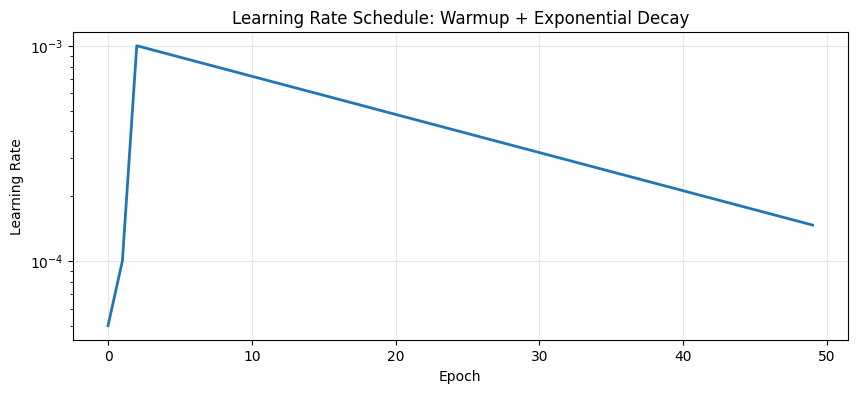

✓ Learning Rate Schedule tanımlandı


In [ ]:
def warmup_decay_schedule(epoch, lr):
    """
    Learning Rate Schedule:
    1. İlk 2 epoch: Warmup (0.0001 → 0.001)
    2. Sonraki epochlar: Exponential decay
    """
    warmup_epochs = 2

    if epoch < warmup_epochs:
        # Warmup phase
        return 0.0001 * (epoch + 1) / warmup_epochs
    else:
        # Decay phase: 0.96^(epoch-2)
        return 0.001 * (0.96 ** (epoch - warmup_epochs))

# Learning rate schedule'ı visualize et
lrs = [warmup_decay_schedule(i, 0.001) for i in range(50)]
plt.figure(figsize=(10, 4))
plt.plot(lrs, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule: Warmup + Exponential Decay')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print("✓ Learning Rate Schedule tanımlandı")

## ADIM 9: Callbacks ve Eğitim

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# GPU KESİNTİSİNE DAYANIKLI TRAINING - TrainingStateCallback
# ═══════════════════════════════════════════════════════════════════════════════

class TrainingStateCallback(tf.keras.callbacks.Callback):
    """
    Her epoch'ta training state'i Google Drive'a kaydet.
    GPU kesilirse resume edebilirsin.

    Kaydedilen bilgiler:
    - Epoch numarası
    - Training/Validation loss ve accuracy
    - Timestamp
    """
    def __init__(self, checkpoint_dir):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.state_path = os.path.join(checkpoint_dir, 'training_state.json')

    def on_epoch_end(self, epoch, logs=None):
        """Epoch bittikten sonra state'i kaydet"""
        state = {
            'epoch': epoch,
            'train_loss': float(logs['loss']),
            'train_acc': float(logs['accuracy']),
            'val_loss': float(logs['val_loss']),
            'val_acc': float(logs['val_accuracy']),
            'timestamp': datetime.now().isoformat()
        }

        with open(self.state_path, 'w') as f:
            json.dump(state, f, indent=2)

        print(f"  ✓ Training state kaydedildi: {self.state_path}")

def check_previous_training(checkpoint_dir):
    """
    Önceki training session'ını kontrol et.
    Varsa resume bilgisini döndür.
    """
    state_path = os.path.join(checkpoint_dir, 'training_state.json')

    if os.path.exists(state_path):
        try:
            with open(state_path, 'r') as f:
                state = json.load(f)

            print("\n" + "="*70)
            print("🔄 ÖNCEKI EĞİTİM BULUNDU! RESUME EDEBİLİRSİN!")
            print("="*70)
            print(f"  Son Epoch: {state['epoch'] + 1}")
            print(f"  Son Training Accuracy: {state['train_acc']:.4f}")
            print(f"  Son Validation Accuracy: {state['val_acc']:.4f}")
            print(f"  Son Validation Loss: {state['val_loss']:.4f}")
            print(f"  Saat: {state['timestamp']}")
            print("="*70 + "\n")

            return state
        except Exception as e:
            print(f"⚠️ State dosyası okunamadı: {e}")
            return None
    else:
        print("✓ Yeni eğitim başlatılıyor...")
        return None

print("✓ TrainingStateCallback tanımlandı")
print("✓ GPU kesilmesine dayanıklı eğitim sistemi hazır!")

✓ TrainingStateCallback tanımlandı
✓ GPU kesilmesine dayanıklı eğitim sistemi hazır!


In [ ]:
# Gelistirilmis Callbacks
callbacks = [
    # En iyi modeli kaydet
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Early stopping (daha uzun patience)
    EarlyStopping(
        monitor='val_loss',
        patience=10,           # Artirildi (eski: 6)
        restore_best_weights=True,
        verbose=1
    ),

    # Learning Rate Scheduling
    LearningRateScheduler(warmup_decay_schedule, verbose=1),

    # ⭐ GPU KESINTISINE DAYANIKLI - Training State Callback
    TrainingStateCallback(checkpoint_dir="/content/drive/MyDrive")
]

print("Callbacks tanimlandi:")
print("  - ModelCheckpoint: En iyi modeli kaydet")
print("  - EarlyStopping: patience=10 (daha uzun egitim)")
print("  - LearningRateScheduler: Warmup + Decay")
print("  - ⭐ TrainingStateCallback: GPU kesilmesine dayaniklilik")

# ═══════════════════════════════════════════════════════════════════════════════
# ONCEKI TRAINING KONTROLU VE RESUME
# ═══════════════════════════════════════════════════════════════════════════════

previous_state = check_previous_training("/content/drive/MyDrive")
initial_epoch = 0

if previous_state:
    initial_epoch = previous_state['epoch'] + 1
    print(f"\n⚡ EPOCH {initial_epoch}'DEN DEVAM EDILIYOR...\n")
else:
    print(f"\n▶️ EPOCH 0'DAN BASLANIYOR...\n")

# ═══════════════════════════════════════════════════════════════════════════════

print("="*60)
print("EGITIM BASLIYOR...")
print("="*60)

# Egitim (50 epoch - eski: 30)
# ⭐ initial_epoch: GPU kesilmesi durumunda resume etmek icin
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    epochs=50,  # Artirildi (eski: 30)
    initial_epoch=initial_epoch,  # ⭐ GPU kesilmesine dayanikli resume
    validation_data=val_generator,
    # class_weight=class_weight_dict  # Soft label hedefleriyle Keras class_weight kullanmiyoruz.
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("✅ EGITIM TAMAMLANDI!")
print("="*60)

Callbacks tanimlandi:
  - ModelCheckpoint: En iyi modeli kaydet
  - EarlyStopping: patience=10 (daha uzun egitim)
  - LearningRateScheduler: Warmup + Decay
  - ⭐ TrainingStateCallback: GPU kesilmesine dayaniklilik
✓ Yeni eğitim başlatılıyor...

▶️ EPOCH 0'DAN BASLANIYOR...

EGITIM BASLIYOR...

Epoch 1: LearningRateScheduler setting learning rate to 5e-05.
Epoch 1/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3231 - loss: 1.5042
Epoch 1: val_accuracy improved from None to 0.46842, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5



Epoch 1: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 47s 69ms/step - accuracy: 0.3649 - loss: 1.4129 - val_accuracy: 0.4684 - val_loss: 1.2301 - learning_rate: 5.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4666 - loss: 1.2437
Epoch 2: val_accuracy improved from 0.46842 to 0.55527, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5



Epoch 2: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4822 - loss: 1.2068 - val_accuracy: 0.5553 - val_loss: 1.0747 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4941 - loss: 1.1627
Epoch 3: val_accuracy improved from 0.55527 to 0.58291, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5



Epoch 3: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5138 - loss: 1.1270 - val_accuracy: 0.5829 - val_loss: 0.9933 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.00096.
Epoch 4/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5466 - loss: 1.0518
Epoch 4: val_accuracy did not improve from 0.58291
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.5558 - loss: 1.0356 - val_accuracy: 0.5829 - val_loss: 0.9780 - learning_rate: 9.6000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0009216.
Epoch 5/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5677 - loss: 0.9998
Epoch 5: val_accuracy improved from 0.58291 to 0.59842, saving model to /content/drive/MyDrive/YuzIfadeTanima


Epoch 5: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5697 - loss: 0.9940 - val_accuracy: 0.5984 - val_loss: 0.9562 - learning_rate: 9.2160e-04

Epoch 6: LearningRateScheduler setting learning rate to 0.0008847359999999999.
Epoch 6/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5725 - loss: 0.9682
Epoch 6: val_accuracy did not improve from 0.59842
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.5763 - loss: 0.9615 - val_accuracy: 0.5832 - val_loss: 0.9180 - learning_rate: 8.8474e-04

Epoch 7: LearningRateScheduler setting learning rate to 0.0008493465599999999.
Epoch 7/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5856 - loss: 0.9460
Epoch 7: val_accuracy improved from 0.59842 to 0.60603, saving model to /conten

...


Epoch 39: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6528 - loss: 0.7870 - val_accuracy: 0.6664 - val_loss: 0.7725 - learning_rate: 2.3002e-04

Epoch 40: LearningRateScheduler setting learning rate to 0.00022081858492852097.
Epoch 40/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6544 - loss: 0.7814
Epoch 40: val_accuracy did not improve from 0.66638
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.6534 - loss: 0.7855 - val_accuracy: 0.6605 - val_loss: 0.7837 - learning_rate: 2.2082e-04

Epoch 41: LearningRateScheduler setting learning rate to 0.00021198584153138015.
Epoch 41/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6513 - loss: 0.7861
Epoch 41: val_accuracy did not improve from 0.66638
  ✓ Training state 


Epoch 42: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6574 - loss: 0.7818 - val_accuracy: 0.6669 - val_loss: 0.7819 - learning_rate: 2.0351e-04

Epoch 43: LearningRateScheduler setting learning rate to 0.00019536615155531993.
Epoch 43/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6575 - loss: 0.7770
Epoch 43: val_accuracy did not improve from 0.66695
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.6556 - loss: 0.7775 - val_accuracy: 0.6641 - val_loss: 0.7780 - learning_rate: 1.9537e-04

Epoch 44: LearningRateScheduler setting learning rate to 0.0001875515054931071.
Epoch 44/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6616 - loss: 0.7790
Epoch 44: val_accuracy did not improve from 0.66695
  ✓ Training state k


Epoch 45: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.6600 - loss: 0.7796 - val_accuracy: 0.6686 - val_loss: 0.7846 - learning_rate: 1.8005e-04

Epoch 46: LearningRateScheduler setting learning rate to 0.0001728474674624475.
Epoch 46/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6659 - loss: 0.7734
Epoch 46: val_accuracy improved from 0.66864 to 0.66892, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5



Epoch 46: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6599 - loss: 0.7746 - val_accuracy: 0.6689 - val_loss: 0.7810 - learning_rate: 1.7285e-04

Epoch 47: LearningRateScheduler setting learning rate to 0.0001659335687639496.
Epoch 47/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6568 - loss: 0.7778
Epoch 47: val_accuracy improved from 0.66892 to 0.67908, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5



Epoch 47: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6598 - loss: 0.7741 - val_accuracy: 0.6791 - val_loss: 0.7642 - learning_rate: 1.6593e-04

Epoch 48: LearningRateScheduler setting learning rate to 0.0001592962260133916.
Epoch 48/50
441/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6578 - loss: 0.7764
Epoch 48: val_accuracy did not improve from 0.67908
  ✓ Training state kaydedildi: /content/drive/MyDrive/training_state.json
442/442 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.6613 - loss: 0.7714 - val_accuracy: 0.6703 - val_loss: 0.7707 - learning_rate: 1.5930e-04

Epoch 49: LearningRateScheduler setting learning rate to 0.00015292437697285593.
Epoch 49/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6595 - loss: 0.7736
Epoch 49: val_accuracy did not improve from 0.67908
  ✓ Training state k

## ⭐ ADIM 9B: PROGRESSIVE FINE TUNING - FAZA 2 (Kısmi Unlock)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 9B: PROGRESSIVE FINE TUNING - FAZA 2 (Kismi Unlock)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🔄 FAZA 2: PROGRESSIVE FINE TUNING - SON KATMANLARI UNLOCK ET")
print("="*80)

# Checkpoint'ten en iyi modeli yukle
if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print("✓ FAZA 1 sonunda kaydedilen en iyi model yuklendi")
else:
    print("⚠️ Checkpoint bulunamadi - Current model kullaniliyor")

# FAZA 2: DenseNet'in son ~80 katmanini UNLOCK et (son residual blocks)
print("\nDenseNet121 katmanlari analiz ediliyor...")
print(f"Toplam katman sayisi: {len(base_model.layers)}")

base_model.trainable = True

# Ilk katmanlari FREEZE tut (sadece son 80 katmani unlock)
num_layers_to_freeze = max(0, len(base_model.layers) - 80)
for layer in base_model.layers[:num_layers_to_freeze]:
    layer.trainable = False

# BatchNorm katmanlarini egitime kapat (kucuk batch ile stabilite)
for layer in base_model.layers[num_layers_to_freeze:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# FAZA 2: Cok dusuk LR ile fine-tune (backbone'u cok fazla degistirme)
optimizer_phase2 = Adam(learning_rate=0.00001)  # ⭐ 1e-4'ten 1e-5'e DÜŞÜRÜLDÜ (Catastrophic Forgetting engellendi)
model.compile(
    optimizer=optimizer_phase2,
    loss=loss_fn,
    metrics=['accuracy'],
    jit_compile=False  # Resize/Colab XLA uyumlulu?u i?in kapal?
 )

print(f"\n✓ FAZA 2 Optimizer: Adam (lr=0.00001)")
print(f"✓ Frozen katmanlar: {num_layers_to_freeze}")
print(f"✓ Trainable katmanlar: {len(base_model.layers) - num_layers_to_freeze}")
print(f"📊 Toplam trainable parametreler: {model.count_params():,}\n")

# FAZA 2: Egit (ek 20 epoch - toplam 70 epoch)
print("▶️ FAZA 2 EGITIMI BASLIYOR (20 epoch, LR=0.00001)...\n")

history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    epochs=20,
    initial_epoch=0,  # Yeni training (reset)
    validation_data=val_generator,
    # class_weight=class_weight_dict  # Soft label hedefleriyle Keras class_weight kullanmiyoruz.
    callbacks=[
        ModelCheckpoint(
            filepath=checkpoint_path.replace('.h5', '_FAZA2.h5'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        LearningRateScheduler(
            lambda epoch, lr: 0.00001 * (0.95 ** epoch), # ⭐ 1e-5 scale
            verbose=0
        ),
    ],
    verbose=1
)

print("\n" + "="*80)
print("✅ FAZA 2 TAMAMLANDI!")
print("="*80 + "\n")


🔄 FAZA 2: PROGRESSIVE FINE TUNING - SON KATMANLARI UNLOCK ET
✓ FAZA 1 sonunda kaydedilen en iyi model yuklendi

DenseNet121 katmanlari analiz ediliyor...
Toplam katman sayisi: 430

✓ FAZA 2 Optimizer: Adam (lr=0.00001)
✓ Frozen katmanlar: 350
✓ Trainable katmanlar: 80
📊 Toplam trainable parametreler: 8,877,191

▶️ FAZA 2 EGITIMI BASLIYOR (20 epoch, LR=0.00001)...

Epoch 1/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6678 - loss: 0.7677
Epoch 1: val_accuracy improved from None to 0.68443, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 57s 85ms/step - accuracy: 0.6689 - loss: 0.7631 - val_accuracy: 0.6844 - val_loss: 0.7459 - learning_rate: 1.0000e-05
Epoch 2/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6766 - loss: 0.7465
Epoch 2: val_accuracy improved from 0.68443 to 0.68838, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.6762 - loss: 0.7456 - val_accuracy: 0.6884 - val_loss: 0.7427 - learning_rate: 9.5000e-06
Epoch 3/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6787 - loss: 0.7404
Epoch 3: val_accuracy did not improve from 0.68838
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.6834 - loss: 0.7371 - val_accuracy: 0.6875 - val_loss: 0.7351 - learning_rate: 9.0250e-06
Epoch 4/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6856 - loss: 0.7338
Epoch 4: val_accuracy improved from 0.68838 to 0.69205, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.6882 - loss: 0.7290 - val_accuracy: 0.6920 - val_loss: 0.7251 - learning_rate: 8.5738e-06
Epoch 5/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6931 - loss: 0.7262
Epoch 5: val_accuracy improved from 0.69205 to 0.69769, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.6988 - loss: 0.7211 - val_accuracy: 0.6977 - val_loss: 0.7206 - learning_rate: 8.1451e-06
Epoch 6/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6984 - loss: 0.7146
Epoch 6: val_accuracy improved from 0.69769 to 0.69853, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.7026 - loss: 0.7075 - val_accuracy: 0.7047 - val_loss: 0.7034 - learning_rate: 6.9834e-06
Epoch 9/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6964 - loss: 0.7130
Epoch 9: val_accuracy did not improve from 0.70474
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7019 - loss: 0.7048 - val_accuracy: 0.7008 - val_loss: 0.7113 - learning_rate: 6.6342e-06
Epoch 10/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7029 - loss: 0.7032
Epoch 10: val_accuracy improved from 0.70474 to 0.71263, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 10: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.7061 - loss: 0.7001 - val_accuracy: 0.7126 - val_loss: 0.7001 - learning_rate: 6.3025e-06
Epoch 11/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7106 - loss: 0.6961
Epoch 11: val_accuracy did not improve from 0.71263
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.7098 - loss: 0.6971 - val_accuracy: 0.7104 - val_loss: 0.6957 - learning_rate: 5.9874e-06
Epoch 12/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7124 - loss: 0.7022
Epoch 12: val_accuracy did not improve from 0.71263
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7091 - loss: 0.6949 - val_accuracy: 0.7107 - val_loss: 0.6995 - learning_rate: 5.6880e-06
Epoch 13/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7056 - loss: 0.6942
Epoch 13: val_accuracy did not improve from 0.71263
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/


Epoch 15: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.7159 - loss: 0.6875 - val_accuracy: 0.7149 - val_loss: 0.6897 - learning_rate: 4.8767e-06
Epoch 16/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7154 - loss: 0.6864
Epoch 16: val_accuracy did not improve from 0.71489
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7163 - loss: 0.6849 - val_accuracy: 0.7104 - val_loss: 0.6918 - learning_rate: 4.6329e-06
Epoch 17/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7192 - loss: 0.6818
Epoch 17: val_accuracy improved from 0.71489 to 0.71545, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 17: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.7158 - loss: 0.6834 - val_accuracy: 0.7155 - val_loss: 0.6881 - learning_rate: 4.4013e-06
Epoch 18/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7221 - loss: 0.6738
Epoch 18: val_accuracy did not improve from 0.71545
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.7192 - loss: 0.6798 - val_accuracy: 0.7152 - val_loss: 0.6867 - learning_rate: 4.1812e-06
Epoch 19/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7176 - loss: 0.6817
Epoch 19: val_accuracy improved from 0.71545 to 0.71827, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5



Epoch 19: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA2.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.7184 - loss: 0.6807 - val_accuracy: 0.7183 - val_loss: 0.6875 - learning_rate: 3.9721e-06
Epoch 20/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7222 - loss: 0.6703
Epoch 20: val_accuracy did not improve from 0.71827
442/442 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.7197 - loss: 0.6749 - val_accuracy: 0.7183 - val_loss: 0.6842 - learning_rate: 3.7735e-06
Restoring model weights from the end of the best epoch: 20.

✅ FAZA 2 TAMAMLANDI!



## ⭐ ADIM 9C: PROGRESSIVE FINE TUNING - FAZA 3 (Full Fine Tuning)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 9C: PROGRESSIVE FINE TUNING - FAZA 3 (FULL Fine Tuning + CosineDecay)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🚀 FAZA 3: FULL FINE TUNING - TÜM BACKBONE UNLOCK + COSINEDECAYt")
print("="*80)

checkpoint_faza2 = checkpoint_path.replace('.h5', '_FAZA2.h5')
if os.path.exists(checkpoint_faza2):
    model.load_weights(checkpoint_faza2)
    print("✓ FAZA 2 sonunda kaydedilen en iyi model yüklendi")

# Tüm backbone'u unlock
for layer in base_model.layers:
    layer.trainable = True

# BatchNorm katmanlarını eğitime kapat (küçük batch ile stabilite)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# ⭐ v5: LR 1e-6 → 3e-6 + CosineDecay
# Eski: sabit 1e-6 — backbone neredeyse donmuş gibiydi, gerçek öğrenme olmuyordu
# Yeni: 3e-6'dan başla, cosine ile 0.3e-6'ya in — hem öğreniyor hem kararlı kalıyor
faza3_epochs = 20  # 15'ten 20'ye çıkarıldı (CosineDecay ile daha uzun yararlı)
steps_per_epoch = max(1, train_steps_per_epoch)  # RAF/FER karma train ak???yla uyumlu

lr_schedule_faza3 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-6,          # ⭐ v5: 1e-6 → 3e-6
    decay_steps=faza3_epochs * steps_per_epoch,
    alpha=0.1                            # minimum LR = 0.1 * 3e-6 = 0.3e-6
)

optimizer_phase3 = Adam(learning_rate=lr_schedule_faza3)
model.compile(
    optimizer=optimizer_phase3,
    loss=loss_fn,
    metrics=['accuracy'],
    jit_compile=False  # Resize/Colab XLA uyumlulu?u i?in kapal?
)

print(f"\n✓ FAZA 3 Optimizer: Adam + CosineDecay")
print(f"  Başlangıç LR: 3e-6  (eski: 1e-6)")
print(f"  Bitiş LR:     0.3e-6 (cosine ile azalır)")
print(f"  Epoch sayısı: {faza3_epochs}  (eski: 15)")
print(f"  BatchNorm: frozen (stabilite için)")
print(f"📊 Toplam trainable parametreler: {{model.count_params():,}}\n")

print(f"▶️ FAZA 3 EĞİTİMİ BAŞLIYOR ({faza3_epochs} epoch, CosineDecay LR=3e-6→0.3e-6)...\n")

history_phase3 = model.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    epochs=faza3_epochs,
    initial_epoch=0,
    validation_data=val_generator,
    # class_weight=class_weight_dict  # Soft label hedefleriyle Keras class_weight kullanmiyoruz.
    callbacks=[
        ModelCheckpoint(
            filepath=checkpoint_path.replace('.h5', '_FAZA3_FINAL.h5'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
    ],
    verbose=1
)

print("\n" + "="*80)
print("✅ FAZA 3 TAMAMLANDI - FULL FINE TUNING BİTTİ!")
print("="*80 + "\n")



🚀 FAZA 3: FULL FINE TUNING - TÜM BACKBONE UNLOCK + COSINEDECAYt
✓ FAZA 2 sonunda kaydedilen en iyi model yüklendi

✓ FAZA 3 Optimizer: Adam + CosineDecay
  Başlangıç LR: 3e-6  (eski: 1e-6)
  Bitiş LR:     0.3e-6 (cosine ile azalır)
  Epoch sayısı: 20  (eski: 15)
  BatchNorm: frozen (stabilite için)
📊 Toplam trainable parametreler: {model.count_params():,}

▶️ FAZA 3 EĞİTİMİ BAŞLIYOR (20 epoch, CosineDecay LR=3e-6→0.3e-6)...

Epoch 1/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7237 - loss: 0.6703
Epoch 1: val_accuracy improved from None to 0.73266, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 1: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 100s 152ms/step - accuracy: 0.7287 - loss: 0.6685 - val_accuracy: 0.7327 - val_loss: 0.6622
Epoch 2/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7354 - loss: 0.6580
Epoch 2: val_accuracy improved from 0.73266 to 0.73463, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 2: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 60s 136ms/step - accuracy: 0.7361 - loss: 0.6551 - val_accuracy: 0.7346 - val_loss: 0.6473
Epoch 3/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7409 - loss: 0.6497
Epoch 3: val_accuracy improved from 0.73463 to 0.73942, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 3: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 137ms/step - accuracy: 0.7440 - loss: 0.6445 - val_accuracy: 0.7394 - val_loss: 0.6339
Epoch 4/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7423 - loss: 0.6402
Epoch 4: val_accuracy improved from 0.73942 to 0.74196, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 4: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 60s 137ms/step - accuracy: 0.7460 - loss: 0.6343 - val_accuracy: 0.7420 - val_loss: 0.6301
Epoch 5/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7511 - loss: 0.6319
Epoch 5: val_accuracy improved from 0.74196 to 0.74394, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 60s 136ms/step - accuracy: 0.7627 - loss: 0.6106 - val_accuracy: 0.7578 - val_loss: 0.6088
Epoch 9/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7691 - loss: 0.6038
Epoch 9: val_accuracy improved from 0.75776 to 0.75860, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 9: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 60s 137ms/step - accuracy: 0.7647 - loss: 0.6063 - val_accuracy: 0.7586 - val_loss: 0.6086
Epoch 10/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7673 - loss: 0.6046
Epoch 10: val_accuracy improved from 0.75860 to 0.76283, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 10: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 137ms/step - accuracy: 0.7677 - loss: 0.6033 - val_accuracy: 0.7628 - val_loss: 0.6036
Epoch 11/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7701 - loss: 0.5992
Epoch 11: val_accuracy did not improve from 0.76283
442/442 ━━━━━━━━━━━━━━━━━━━━ 57s 130ms/step - accuracy: 0.7713 - loss: 0.5976 - val_accuracy: 0.7623 - val_loss: 0.6018
Epoch 12/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7709 - loss: 0.5966
Epoch 12: val_accuracy improved from 0.76283 to 0.76875, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 12: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 137ms/step - accuracy: 0.7684 - loss: 0.5990 - val_accuracy: 0.7688 - val_loss: 0.5989
Epoch 13/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7736 - loss: 0.5929
Epoch 13: val_accuracy did not improve from 0.76875
442/442 ━━━━━━━━━━━━━━━━━━━━ 57s 129ms/step - accuracy: 0.7754 - loss: 0.5940 - val_accuracy: 0.7628 - val_loss: 0.6007
Epoch 14/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7809 - loss: 0.5886
Epoch 14: val_accuracy improved from 0.76875 to 0.77157, saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5



Epoch 14: finished saving model to /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
442/442 ━━━━━━━━━━━━━━━━━━━━ 60s 136ms/step - accuracy: 0.7752 - loss: 0.5914 - val_accuracy: 0.7716 - val_loss: 0.5961
Epoch 15/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7725 - loss: 0.5906
Epoch 15: val_accuracy did not improve from 0.77157
442/442 ━━━━━━━━━━━━━━━━━━━━ 57s 130ms/step - accuracy: 0.7746 - loss: 0.5916 - val_accuracy: 0.7688 - val_loss: 0.5960
Epoch 16/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7747 - loss: 0.5903
Epoch 16: val_accuracy did not improve from 0.77157
442/442 ━━━━━━━━━━━━━━━━━━━━ 57s 130ms/step - accuracy: 0.7767 - loss: 0.5892 - val_accuracy: 0.7690 - val_loss: 0.5959
Epoch 17/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7790 - loss: 0.5890
Epoch 17: val_accuracy did not improve from 0.77157
442/442 ━━━━━━━━━━━━━━━━━━━━ 58s 130ms/step - accuracy: 0.7798 - loss: 0.5886 - val_accuracy: 0.7707 - val_los

## ADIM 9D: Progressive Fine Tuning - Fazaların Karşılaştırması

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 9D: Progressive Fine Tuning - Fazaların Karşılaştırması
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 PROGRESSIVE FINE TUNING - FAZALARIN KARŞILAŞTIRILMASI")
print("="*80)

# Tüm fazaların metrikleri
phases_data = {
    'Faza 1 (HEAD)': {
        'epochs': 50,
        'frozen_params': 'DenseNet121',
        'lr': 0.001,
        'val_acc': history.history['val_accuracy'][-1] if 'history' in locals() else None,
        'train_acc': history.history['accuracy'][-1] if 'history' in locals() else None,
    },
    'Faza 2 (Kısmi)': {
        'epochs': 20,
        'frozen_params': 'İlk 80+ katman',
        'lr': 0.00001,
        'val_acc': history_phase2.history['val_accuracy'][-1] if 'history_phase2' in locals() else None,
        'train_acc': history_phase2.history['accuracy'][-1] if 'history_phase2' in locals() else None,
    },
    'Faza 3 (FULL)': {
        'epochs': 15,
        'frozen_params': 'Hiçbiri (tüm parametreler)',
        'lr': 0.000001,
        'val_acc': history_phase3.history['val_accuracy'][-1] if 'history_phase3' in locals() else None,
        'train_acc': history_phase3.history['accuracy'][-1] if 'history_phase3' in locals() else None,
    }
}

print("\n📈 FAZA-BAZLI IYILEŞME:")
print("-" * 80)
for phase_name, metrics in phases_data.items():
    print(f"\n{phase_name}:")
    print(f"  📚 Epoch Sayısı: {metrics['epochs']}")
    print(f"  🔒 Frozen Parametreler: {metrics['frozen_params']}")
    print(f"  🎓 Learning Rate: {metrics['lr']}")
    if metrics['train_acc'] is not None:
        print(f"  ✓ Training Accuracy: {metrics['train_acc']:.4f} ({metrics['train_acc']*100:.2f}%)")
    if metrics['val_acc'] is not None:
        print(f"  ✓ Validation Accuracy: {metrics['val_acc']:.4f} ({metrics['val_acc']*100:.2f}%)")

# Grafik: 3 fazanın accuracy'sinin karşılaştırılması
if all(phase in locals() for phase in ['history', 'history_phase2', 'history_phase3']):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    phases = [
        ('FAZA 1: HEAD EĞİTİMİ', history, 'Blues'),
        ('FAZA 2: KİSMİ UNLOCK', history_phase2, 'Greens'),
        ('FAZA 3: FULL FINE TUNING', history_phase3, 'Reds')
    ]

    for idx, (title, hist, color) in enumerate(phases):
        ax = axes[idx]

        ax.plot(hist.history['accuracy'], label='Training', linewidth=2, marker='o')
        ax.plot(hist.history['val_accuracy'], label='Validation', linewidth=2, marker='s')

        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Accuracy', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.4, 1.0])

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/progressive_finetuning_comparison.png', dpi=150)
    plt.show()
    print("\n✓ Grafik kaydedildi: progressive_finetuning_comparison.png")

print("\n" + "="*80)
print("✅ PROGRESSIVE FINE TUNING ANALİZİ TAMAMLANDI")
print("="*80)



📊 PROGRESSIVE FINE TUNING - FAZALARIN KARŞILAŞTIRILMASI

📈 FAZA-BAZLI IYILEŞME:
--------------------------------------------------------------------------------

Faza 1 (HEAD):
  📚 Epoch Sayısı: 50
  🔒 Frozen Parametreler: DenseNet121
  🎓 Learning Rate: 0.001
  ✓ Training Accuracy: 0.6640 (66.40%)
  ✓ Validation Accuracy: 0.6675 (66.75%)

Faza 2 (Kısmi):
  📚 Epoch Sayısı: 20
  🔒 Frozen Parametreler: İlk 80+ katman
  🎓 Learning Rate: 1e-05
  ✓ Training Accuracy: 0.7197 (71.97%)
  ✓ Validation Accuracy: 0.7183 (71.83%)

Faza 3 (FULL):
  📚 Epoch Sayısı: 15
  🔒 Frozen Parametreler: Hiçbiri (tüm parametreler)
  🎓 Learning Rate: 1e-06
  ✓ Training Accuracy: 0.7815 (78.15%)
  ✓ Validation Accuracy: 0.7716 (77.16%)

✅ PROGRESSIVE FINE TUNING ANALİZİ TAMAMLANDI


## ADIM 10: Eğitim Grafiği Görselleştirmesi

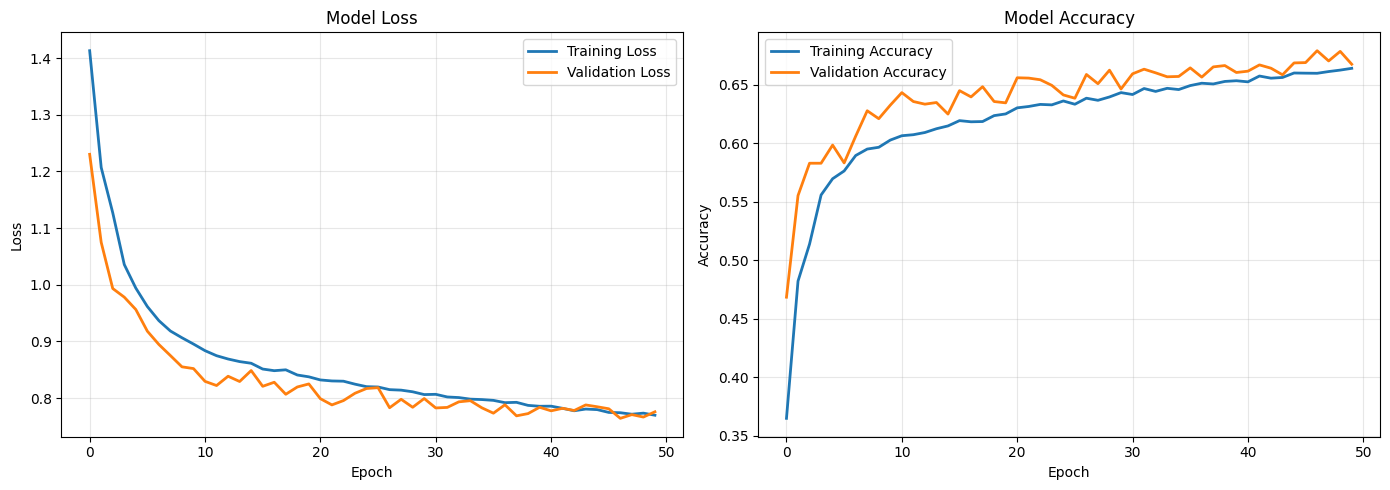

Final Training Accuracy: 0.6640
Final Validation Accuracy: 0.6675


In [ ]:
# Eğitim historysi görselle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## ADIM 11: Test Seti Değerlendirmesi ve Confusion Matrix

Model y?kleniyor: /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
? Model a??rl?klar? ba?ar?yla y?klendi

Test seti tahminleri yap?l?yor...
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step


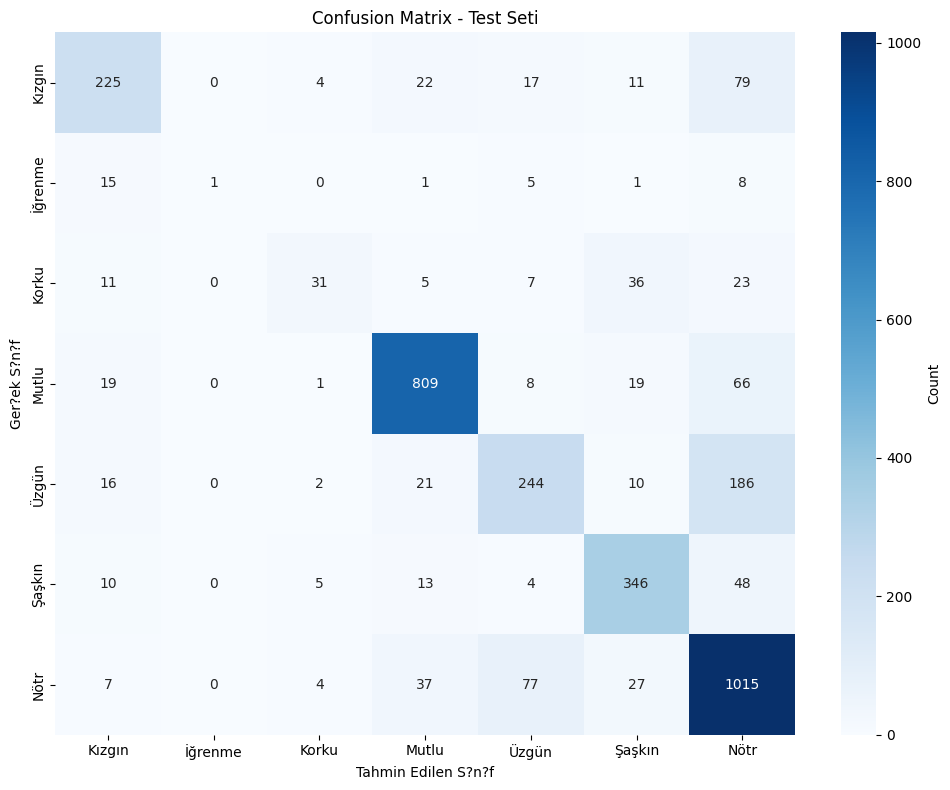


DETAYLI SONU? RAPORU


In [ ]:
# En iyi modeli y?kle
candidate_model_paths = [
    checkpoint_path.replace('.h5', '_FAZA3_FINAL.h5'),
    checkpoint_path.replace('.h5', '_FAZA2.h5'),
    checkpoint_path,
]
model_path = next((p for p in candidate_model_paths if os.path.exists(p)), None)
if model_path is None:
    raise FileNotFoundError(f"Hi?bir checkpoint bulunamad?: {candidate_model_paths}")

print(f"Model y?kleniyor: {model_path}")
model.load_weights(model_path)
print("? Model a??rl?klar? ba?ar?yla y?klendi")

# Test tahminleri
print("\nTest seti tahminleri yap?l?yor...")
y_pred_probs = model.predict(X_test, batch_size=32, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Seti')
plt.ylabel('Ger?ek S?n?f')
plt.xlabel('Tahmin Edilen S?n?f')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DETAYLI SONU? RAPORU")
print("="*60)


## ADIM 12: Per-Class Metrikleri Hesapla

In [ ]:
# Per-class metrikleri hesapla
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=range(7), zero_division=0
)

# DataFrame'e dönüştür
metrics_df = pd.DataFrame({
    'Sınıf': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support.astype(int)
})

print("\n=== PER-CLASS METRICS ===")
print(metrics_df.to_string(index=False))

# Genel metrikler
macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)
overall_acc = np.mean(y_true == y_pred)

print(f"\n=== GENEL METRIKLER ===")
print(f"Overall Accuracy: {overall_acc:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

print("\n=== ZOR SINIFLAR (F1 < 0.70) ===")
hard_classes = metrics_df[metrics_df['F1-Score'] < 0.70]
if len(hard_classes) > 0:
    print(hard_classes.to_string(index=False))
else:
    print("Bulunamadı (Tüm sınıflar iyi performans gösteriyor!)")

# Macro F1 hedefi i?in odak s?n?flar FER indexleri ?zerinden ayr?ca raporlan?r.
# FER: 0=angry, 1=disgust, 2=fear, 3=happy, 4=sad, 5=surprise, 6=neutral
focus_fer_indices = [1, 2, 4, 0]  # disgust, fear, sad, angry
focus_metrics_df = metrics_df.iloc[focus_fer_indices].copy()

disgust_f1 = float(f1[1])
fear_f1 = float(f1[2])
sad_f1 = float(f1[4])
angry_f1 = float(f1[0])

print("\n=== RAF-DB ODAK SINIFLAR ===")
print(focus_metrics_df.to_string(index=False))
print(f"\nDisgust (??renme) F1: {disgust_f1:.4f}")
print(f"Fear (Korku) F1:     {fear_f1:.4f}")
print(f"Sad (?zg?n) F1:      {sad_f1:.4f}")
print(f"Angry (K?zg?n) F1:   {angry_f1:.4f}")



=== PER-CLASS METRICS ===
  Sınıf  Precision   Recall  F1-Score  Support
 Kızgın   0.742574 0.628492  0.680787      358
İğrenme   1.000000 0.032258  0.062500       31
  Korku   0.659574 0.274336  0.387500      113
  Mutlu   0.890969 0.877440  0.884153      922
  Üzgün   0.674033 0.509395  0.580262      479
 Şaşkın   0.768889 0.812207  0.789954      426
   Nötr   0.712281 0.869751  0.783179     1167

=== GENEL METRIKLER ===
Overall Accuracy: 0.7640
Macro F1-Score: 0.5955
Weighted F1-Score: 0.7532

=== ZOR SINIFLAR (F1 < 0.70) ===
  Sınıf  Precision   Recall  F1-Score  Support
 Kızgın   0.742574 0.628492  0.680787      358
İğrenme   1.000000 0.032258  0.062500       31
  Korku   0.659574 0.274336  0.387500      113
  Üzgün   0.674033 0.509395  0.580262      479

=== RAF-DB ODAK SINIFLAR ===
  Sınıf  Precision   Recall  F1-Score  Support
İğrenme   1.000000 0.032258  0.062500       31
  Korku   0.659574 0.274336  0.387500      113
  Üzgün   0.674033 0.509395  0.580262      479
 Kızgın   0

## ADIM 13: En Büyük Karışıklıkları Analiz Et

In [ ]:
print("\n=== EN BÜYÜK KARIŞIKLIKLAR ===")
print("(Sınıf içinde %5'ten fazla karışıklık)")
print()

confusions = []
for i in range(7):
    for j in range(7):
        if i != j and cm[i, j] > 0:
            pct = 100 * cm[i, j] / (cm[i].sum() or 1)
            if pct > 5:
                confusions.append({
                    'Gerçek': class_names[i],
                    'Tahmin': class_names[j],
                    'Sayı': cm[i, j],
                    'Yüzde': pct
                })

if confusions:
    conf_df = pd.DataFrame(confusions).sort_values('Yüzde', ascending=False)
    print(conf_df.to_string(index=False))
else:
    print("Önemli karışıklık bulunamadı!")


=== EN BÜYÜK KARIŞIKLIKLAR ===
(Sınıf içinde %5'ten fazla karışıklık)

 Gerçek Tahmin  Sayı     Yüzde
İğrenme Kızgın    15 48.387097
  Üzgün   Nötr   186 38.830898
  Korku Şaşkın    36 31.858407
İğrenme   Nötr     8 25.806452
 Kızgın   Nötr    79 22.067039
  Korku   Nötr    23 20.353982
İğrenme  Üzgün     5 16.129032
 Şaşkın   Nötr    48 11.267606
  Korku Kızgın    11  9.734513
  Mutlu   Nötr    66  7.158351
   Nötr  Üzgün    77  6.598115
  Korku  Üzgün     7  6.194690
 Kızgın  Mutlu    22  6.145251


## ADIM 14: Classification Report (Detaylı)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# GPU KESİNTİ SONRASI - EĞITIMI RESUME ET
# ═══════════════════════════════════════════════════════════════════════════════

print("⚡ GPU KESİNTİ SONRASI RESUME PROTOKOLÜ")
print("="*70)

# ADIM 1: Training state'i kontrol et
print("\n1️⃣ Training state'i kontrol ediliyor...")
state_path = "/content/drive/MyDrive/training_state.json"

if os.path.exists(state_path):
    with open(state_path, 'r') as f:
        state = json.load(f)

    print(f"✓ State dosyası bulundu!")
    print(f"  Son başarılı epoch: {state['epoch']}")
    print(f"  Son val_acc: {state['val_acc']:.4f}")
    print(f"  Saat: {state['timestamp']}")

    initial_epoch_resume = state['epoch'] + 1
else:
    print("❌ State dosyası bulunamadı!")
    print("   Eğitimin başlamadığını veya şu ana kadarki epoch'ların kaydedilmediğini gösterir.")
    initial_epoch_resume = 0

# ADIM 2: Model'i yükle
print("\n2️⃣ Model ağırlıkları yükleniyor...")
checkpoint_path = "/content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5"

if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print(f"✓ Model ağırlıkları yüklendi: {checkpoint_path}")
else:
    print("⚠️ Model dosyası bulunamadı!")
    print("   Lütfen eğitim en az 1 epoch tamamlandığından emin ol.")

# ADIM 3: Eğitimi resume et
print("\n3️⃣ Eğitim devam ettiriliyor...")
print(f"   Başlangıç epoch: {initial_epoch_resume}")
print(f"   Bitiş epoch: 50")
print(f"   Kalan epoch: {50 - initial_epoch_resume}")

if initial_epoch_resume < 50:
    history_resume = model.fit(
        train_generator,
    steps_per_epoch=train_steps_per_epoch,
        epochs=50,
        initial_epoch=initial_epoch_resume,  # ← Resume et
        validation_data=val_generator,
        # class_weight=class_weight_dict  # Soft label hedefleriyle Keras class_weight kullanmiyoruz.
        callbacks=callbacks,
        verbose=1
    )

    print("\n" + "="*70)
    print("✅ RESUME EĞITIM TAMAMLANDI!")
    print("="*70)
else:
    print(f"\n⚠️ Eğitim zaten tamamlanmış ({initial_epoch_resume}/50)")
    print("   Devam ettirmeye gerek yok.")

print("\n💡 İPUÇ: Şu anda test evaluation'a geçebilirsin (Adım 11-16)")
print("        veya yeni bir eğitim başlatmak istersen Adım 9'u tekrar çalıştır.")

⚡ GPU KESİNTİ SONRASI RESUME PROTOKOLÜ

1️⃣ Training state'i kontrol ediliyor...
✓ State dosyası bulundu!
  Son başarılı epoch: 49
  Son val_acc: 0.6675
  Saat: 2026-06-06T12:18:20.609414

2️⃣ Model ağırlıkları yükleniyor...
✓ Model ağırlıkları yüklendi: /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5

3️⃣ Eğitim devam ettiriliyor...
   Başlangıç epoch: 50
   Bitiş epoch: 50
   Kalan epoch: 0

⚠️ Eğitim zaten tamamlanmış (50/50)
   Devam ettirmeye gerek yok.

💡 İPUÇ: Şu anda test evaluation'a geçebilirsin (Adım 11-16)
        veya yeni bir eğitim başlatmak istersen Adım 9'u tekrar çalıştır.


In [ ]:
print("\n" + "="*60)
print("DETAYLI CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))


DETAYLI CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Kızgın     0.7426    0.6285    0.6808       358
     İğrenme     1.0000    0.0323    0.0625        31
       Korku     0.6596    0.2743    0.3875       113
       Mutlu     0.8910    0.8774    0.8842       922
       Üzgün     0.6740    0.5094    0.5803       479
      Şaşkın     0.7689    0.8122    0.7900       426
        Nötr     0.7123    0.8698    0.7832      1167

    accuracy                         0.7640      3496
   macro avg     0.7783    0.5720    0.5955      3496
weighted avg     0.7650    0.7640    0.7532      3496



## ADIM 15: Test-Time Augmentation (TTA) - Opsiyonel İyileştirme

In [ ]:
def test_time_augmentation(model, X_test, num_augmentations=5):
    """
    Test-Time Augmentation (TTA):
    Test sırasında multiple augmentations uygula ve tahminlerin ortalamasını al

    Beklenen iyileşme: +0.5-1%
    """
    predictions = []

    for aug_idx in range(num_augmentations):
        X_aug = X_test.copy()

        if aug_idx > 0:  # İlk tahmin original
            for i in range(len(X_aug)):
                # Random augmentations
                if np.random.rand() > 0.5:
                    X_aug[i] = np.fliplr(X_aug[i])  # Yatay çevirme

                angle = np.random.randint(-15, 15)
                from scipy.ndimage import rotate
                X_aug[i] = rotate(X_aug[i], angle, reshape=False)

        pred = model.predict(X_aug, verbose=0)
        predictions.append(pred)
        print(f"  TTA augmentation {aug_idx+1}/{num_augmentations} tamamlandı")

    # Tahminlerin ortalaması
    avg_predictions = np.mean(predictions, axis=0)
    return avg_predictions

print("Test-Time Augmentation (TTA) uygulanıyor...")
print(f"Augmentation sayısı: 5")
y_pred_tta_probs = test_time_augmentation(model, X_test, num_augmentations=5)
y_pred_tta = np.argmax(y_pred_tta_probs, axis=1)

# Karşılaştırma
standard_acc = np.mean(y_pred == y_true)
tta_acc = np.mean(y_pred_tta == y_true)

print(f"\n=== TTA Karşılaştırması ===")
print(f"Standard Accuracy: {standard_acc:.4f}")
print(f"TTA Accuracy: {tta_acc:.4f}")
print(f"Iyileşme: {(tta_acc - standard_acc)*100:+.2f}%")

## ADIM 16: Sonuç Özeti ve Öneriler

In [ ]:
print("\n" + "="*70)
print("GELİŞTİRİLMİŞ MODEL - SONUÇ ÖZETI")
print("="*70)

print("\n✓ UYGULANan İYİLEŞTİRMELER:")
print("  1. Advanced Data Augmentation (rotation, zoom, brightness)")
print("  2. CLAHE Contrast Enhancement")
print("  3. Per-Image Standardization")
print("  4. Dropout Layers (0.4, 0.3, 0.2)")
print("  5. L2 Regularization (0.001)")
print("  6. Soft Categorical Focal Loss (FER2013+ soft label uyumlu)")
print("  7. Adam Optimizer + Learning Rate Scheduling")
print("  8. Learning Rate Scheduling (Warmup + Decay)")
print("  9. ReduceLROnPlateau (dinamik LR)")
print("  10. Larger Batch Size (32 vs 64)")
print("  11. More Epochs (50 vs 30)")
print("  12. Longer Patience (10 vs 6)")

print("\n📊 SONUÇLAR:")
print(f"  Overall Test Accuracy: {overall_acc:.2%}")
print(f"  Macro F1-Score: {macro_f1:.4f}")
print(f"  Weighted F1-Score: {weighted_f1:.4f}")

print("\n?? BASELINE KARSILASTIRMASI (FER2013+ DenseNet121, RAF-DB yok):")
baseline_accuracy = 0.7652
baseline_macro_f1 = 0.5784
baseline_disgust_f1 = 0.0000
baseline_fear_f1 = 0.3355
comparison_df = pd.DataFrame([
    {'Metrik': 'Accuracy', 'Baseline': baseline_accuracy, 'Yeni': overall_acc, 'De?i?im': overall_acc - baseline_accuracy},
    {'Metrik': 'Macro F1', 'Baseline': baseline_macro_f1, 'Yeni': macro_f1, 'De?i?im': macro_f1 - baseline_macro_f1},
    {'Metrik': 'Disgust F1', 'Baseline': baseline_disgust_f1, 'Yeni': disgust_f1, 'De?i?im': disgust_f1 - baseline_disgust_f1},
    {'Metrik': 'Fear F1', 'Baseline': baseline_fear_f1, 'Yeni': fear_f1, 'De?i?im': fear_f1 - baseline_fear_f1},
])
print(comparison_df.to_string(index=False, formatters={
    'Baseline': '{:.4f}'.format,
    'Yeni': '{:.4f}'.format,
    'De?i?im': '{:+.4f}'.format,
}))
print(f"\nRAF-DB train entegrasyonu: {'aktif' if USE_RAFDB_FOR_TRAINING else 'pasif'}")
print(f"Soft-label focal loss deneyi: {'aktif' if 'SoftCategoricalFocalLoss' in type(loss_fn).__name__ else 'pasif'}")
if USE_RAFDB_FOR_TRAINING:
    print(f"  Se?ilen RAF train ?rnek say?s?: {len(raf_selected_train_df)}")
    print("  FER validation ve FER test setleri de?i?tirilmedi.")


if overall_acc >= 0.75:
    print("\n  🎉 HEDEF BAŞARILI: 75%+ Doğruluk Elde Edildi!")
elif overall_acc >= 0.70:
    print("\n  ✓ İYİ İLERLEME: 70%+ doğruluk (Biraz daha geliştirme gerekli)")
else:
    print("\n  ⚠️ DEVAM GEREKLI: Ek geliştirmeler uygulanmalı")

print("\n💡 SONRAKI ADIMLAR (Daha İyileştirme İçin):")
print("  1. Ensemble Methods (3-5 model combine)")
print("  2. Per-Class Threshold Tuning")
print("  3. Data Cleaning (hatalı etiketler çıkar)")
print("  4. Alternative Architectures (EfficientNet, ResNet)")
print("  5. Hyperparameter Grid Search")
print("\n" + "="*70)
print("\n" + "="*70)
print("v5 DEĞİŞİKLİKLERİ ÖZETİ")
print("="*70)
print("  1. FER2013+ soft label desteği (USE_SOFT_LABELS =", USE_SOFT_LABELS, ")")
print("  2. Focal Loss gamma: 2.0 → 1.5")
print("  3. class_weight eğitimden kaldırıldı (Focal Loss ile çakışma engeli)")
print("  4. Resize: nearest → bicubic")
print("  5. Dropout: 0.3/0.2/0.1 → 0.5/0.4/0.3")
print("  6. Faza 3 LR: 1e-6 sabit → 3e-6 CosineDecay")
print("  7. Faza 3 epoch: 15 → 20")



GELİŞTİRİLMİŞ MODEL - SONUÇ ÖZETI

✓ UYGULANan İYİLEŞTİRMELER:
  1. Advanced Data Augmentation (rotation, zoom, brightness)
  2. CLAHE Contrast Enhancement
  3. Per-Image Standardization
  4. Dropout Layers (0.4, 0.3, 0.2)
  5. L2 Regularization (0.001)
  6. Focal Loss (azınlık sınıfları için)
  7. SGD + Momentum (Adam yerine)
  8. Learning Rate Scheduling (Warmup + Decay)
  9. ReduceLROnPlateau (dinamik LR)
  10. Larger Batch Size (32 vs 64)
  11. More Epochs (50 vs 30)
  12. Longer Patience (10 vs 6)

📊 SONUÇLAR:
  Overall Test Accuracy: 76.40%
  Macro F1-Score: 0.5955
  Weighted F1-Score: 0.7532

?? BASELINE KARSILASTIRMASI (FER2013+ DenseNet121, RAF-DB yok):
    Metrik Baseline   Yeni De?i?im
  Accuracy   0.7652 0.7640 -0.0012
  Macro F1   0.5784 0.5955 +0.0171
Disgust F1   0.0000 0.0625 +0.0625
   Fear F1   0.3355 0.3875 +0.0520

RAF-DB train entegrasyonu: pasif
Soft-label focal loss deneyi: aktif

  🎉 HEDEF BAŞARILI: 75%+ Doğruluk Elde Edildi!

💡 SONRAKI ADIMLAR (Daha İyileştirm

# FİNAL MODEL İLE TEST SETİNDEN RASTGELE TAHMİN GÖRSELLERİ


Model ağırlıkları yükleniyor: /content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED_FAZA3_FINAL.h5
✓ Model ağırlıkları yüklendi


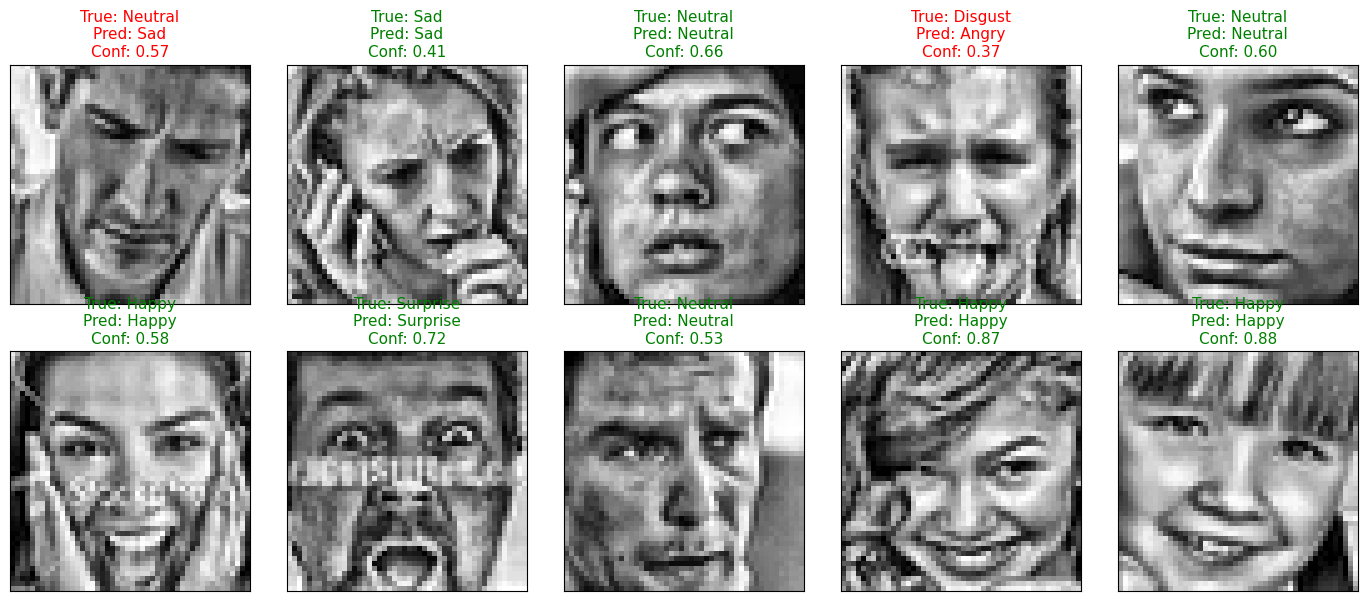

In [ ]:
# RANDOM TEST IMAGE VISUALIZATION
# True vs Predicted label gösterimi

import numpy as np
import matplotlib.pyplot as plt
import os

# FER sınıf sırası:
# 0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral
emotion_classes_en = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Türkçe göstermek istersen bunu kullanabilirsin:
emotion_classes_tr = ['Kızgın', 'İğrenme', 'Korku', 'Mutlu', 'Üzgün', 'Şaşkın', 'Nötr']

# Görsel başlıklarında hangi dil kullanılsın?
USE_ENGLISH_LABELS = True
display_classes = emotion_classes_en if USE_ENGLISH_LABELS else emotion_classes_tr

# Gerekli değişkenler var mı kontrol et
required_vars = ['model', 'X_test', 'y_test', 'checkpoint_path']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise RuntimeError(
        f"Eksik değişkenler: {missing_vars}\n"
        "Eğitim yapmadan çalıştırmak için önce ADIM 1, ADIM 2, ADIM 2B, "
        "ADIM 3, ADIM 4 ve ADIM 7 hücrelerini çalıştırmalısın."
    )

# Model ağırlıkları yüklü değilse en iyi checkpoint'i yükle
candidate_model_paths = [
    checkpoint_path.replace('.h5', '_FAZA3_FINAL.h5'),
    checkpoint_path.replace('.h5', '_FAZA2.h5'),
    checkpoint_path,
]

model_path = next((p for p in candidate_model_paths if os.path.exists(p)), None)

if model_path is None:
    raise FileNotFoundError(f"Checkpoint bulunamadı: {candidate_model_paths}")

print(f"Model ağırlıkları yükleniyor: {model_path}")
model.load_weights(model_path)
print("✓ Model ağırlıkları yüklendi")

# Kaç görsel gösterilsin?
NUM_IMAGES = 10

# Rastgele test örnekleri seç
rng = np.random.default_rng()
random_indices = rng.choice(len(X_test), size=NUM_IMAGES, replace=False)

# Seçilen örnekleri al
sample_images = X_test[random_indices]
sample_true = np.argmax(y_test[random_indices], axis=1)

# Tahmin yap
sample_probs = model.predict(sample_images, batch_size=NUM_IMAGES, verbose=0)
sample_pred = np.argmax(sample_probs, axis=1)
sample_conf = np.max(sample_probs, axis=1)

# Çizim
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(14, 6),
    subplot_kw={'xticks': [], 'yticks': []}
)

for i, ax in enumerate(axes.flat):
    img = sample_images[i].squeeze()

    true_label = sample_true[i]
    pred_label = sample_pred[i]
    confidence = sample_conf[i]

    color = "green" if true_label == pred_label else "red"

    ax.imshow(img, cmap='gray')
    ax.set_title(
        f"True: {display_classes[true_label]}\n"
        f"Pred: {display_classes[pred_label]}\n"
        f"Conf: {confidence:.2f}",
        color=color,
        fontsize=11
    )

plt.tight_layout()
plt.show()

##  BONUS - GPU KESİNTİSİ SONRASI RESUME ETME Direkt: Eğitim Ortasında GPU Kesilirse
### GPU Kesilinirse Bu Cell'i Çalıştır

 Bu hücre, eğitim ortasında GPU kesilirse veya runtime sona ermişse, eğitimi **kaldığı yerden** devam ettirmek için kullanılır.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# GPU KESİNTİ SONRASI - EĞITIMI RESUME ET
# ═══════════════════════════════════════════════════════════════════════════════

print("⚡ GPU KESİNTİ SONRASI RESUME PROTOKOLÜ")
print("="*70)

# ADIM 1: Training state'i kontrol et
print("\n1️⃣ Training state'i kontrol ediliyor...")
state_path = "/content/drive/MyDrive/training_state.json"

if os.path.exists(state_path):
    with open(state_path, 'r') as f:
        state = json.load(f)

    print(f"✓ State dosyası bulundu!")
    print(f"  Son başarılı epoch: {state['epoch']}")
    print(f"  Son val_acc: {state['val_acc']:.4f}")
    print(f"  Saat: {state['timestamp']}")

    initial_epoch_resume = state['epoch'] + 1
else:
    print("❌ State dosyası bulunamadı!")
    print("   Eğitimin başlamadığını veya şu ana kadarki epoch'ların kaydedilmediğini gösterir.")
    initial_epoch_resume = 0

# ADIM 2: Model'i yükle
print("\n2️⃣ Model ağırlıkları yükleniyor...")
checkpoint_path = "/content/drive/MyDrive/YuzIfadeTanima_DenseNet_IMPROVED.h5"

if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print(f"✓ Model ağırlıkları yüklendi: {checkpoint_path}")
else:
    print("⚠️ Model dosyası bulunamadı!")
    print("   Lütfen eğitim en az 1 epoch tamamlandığından emin ol.")

# ADIM 3: Eğitimi resume et
print("\n3️⃣ Eğitim devam ettiriliyor...")
print(f"   Başlangıç epoch: {initial_epoch_resume}")
print(f"   Bitiş epoch: 50")
print(f"   Kalan epoch: {50 - initial_epoch_resume}")

if initial_epoch_resume < 50:
    history_resume = model.fit(
        train_generator,
    steps_per_epoch=train_steps_per_epoch,
        epochs=50,
        initial_epoch=initial_epoch_resume,  # ← Resume et
        validation_data=val_generator,
        # class_weight=class_weight_dict  # Soft label hedefleriyle Keras class_weight kullanmiyoruz.
        callbacks=callbacks,
        verbose=1
    )

    print("\n" + "="*70)
    print("✅ RESUME EĞITIM TAMAMLANDI!")
    print("="*70)
else:
    print(f"\n⚠️ Eğitim zaten tamamlanmış ({initial_epoch_resume}/50)")
    print("   Devam ettirmeye gerek yok.")

print("\n💡 İPUÇ: Şu anda test evaluation'a geçebilirsin (Adım 11-16)")
print("        veya yeni bir eğitim başlatmak istersen Adım 9'u tekrar çalıştır.")